# RX-PAD French Medical Prescriptions Benchmark Analysis

Executive Summary

**Dataset:** RX-PAD - French Medical Prescriptions  
**Total Samples:** 200 prescription images per phase  
**Task:** OCR and information extraction from French medical prescriptions  
**Evaluation Metrics:** CER (Character Error Rate), WER (Word Error Rate), Cosine Similarity

## Benchmark Structure

### Phase Pa: OCR Baseline (Pure OCR Models)
- **Models:** Azure Document Intelligence, Mistral Document AI
- **Approach:** Direct OCR on French medical prescription text
- **Purpose:** Establish baseline OCR performance for French medical documents

### Phase Pb: VLM Baseline (Generic Prompting)
- **Models:** GPT-5-mini, GPT-5-nano, Claude Sonnet  
- **Prompt:** Generic French text extraction (no medical context)
- **Purpose:** Evaluate general-purpose VLM capabilities for French prescription text

### Phase Pc: VLM with Medical Context
- **Models:** GPT-5-mini, GPT-5-nano, Claude Sonnet
- **Prompt:** Specifies language (French) + document type (Medical Prescription)
- **Purpose:** Test if medical domain context improves field extraction

# 1. Imports and Metadata

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import sys
from pathlib import Path
from typing import List, Dict, Optional, Tuple
import warnings
warnings.filterwarnings('ignore')

# Progress bar for long operations
from tqdm.notebook import tqdm

# Add parent directory to path for imports
sys.path.insert(0, str(Path.cwd().parent.parent.parent))

# Import evaluation metrics
from ocr_vs_vlm.metrics.evaluation_metrics import (
    calculate_cer,
    calculate_wer,
    compute_anls,
    compute_exact_match,
    compute_ground_truth_in_prediction
)

# Import embedding cache manager for efficient cosine similarity computation
from ocr_vs_vlm.metrics.embedding_cache import EmbeddingCacheManager

# Model ordering configuration for consistent display
MODEL_ORDER = ['azure_intelligence', 'mistral_document_ai', 'donut', 'gpt-5-nano', 'gpt-5-mini', 'claude_sonnet', 'claude_haiku']

def sort_models(models: List[str]) -> List[str]:
    """Sort models according to MODEL_ORDER."""
    def sort_key(model):
        try:
            return MODEL_ORDER.index(model)
        except ValueError:
            return len(MODEL_ORDER)  # Unknown models go to the end
    return sorted(models, key=sort_key)

def get_model_display_name(model: str) -> str:
    """Get display name for model."""
    display_names = {
        'azure_intelligence': 'Azure Intelligence',
        'mistral_document_ai': 'Mistral Document AI',
        'donut': 'Donut',
        'gpt-5-nano': 'GPT-5 Nano',
        'gpt-5-mini': 'GPT-5 Mini',
        'claude_sonnet': 'Claude Sonnet',
        'claude_haiku': 'Claude Haiku'
    }
    return display_names.get(model, model)

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 100)
pd.set_option('display.width', 1000)

# Plotting style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11
sns.set_palette('husl')

# Support French characters in plots
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

print("✓ Libraries and evaluation metrics loaded successfully!")
print(f"✓ Model display order: {', '.join(MODEL_ORDER)}")

✓ Libraries and evaluation metrics loaded successfully!
✓ Model display order: azure_intelligence, mistral_document_ai, donut, gpt-5-nano, gpt-5-mini, claude_sonnet, claude_haiku


### Load all phase files and explore the dataset structure.

In [19]:
# Define paths
RESULTS_DIR = Path("../../2_clean/RX-PAD")

# Check available files
available_files = list(RESULTS_DIR.glob("*.csv"))
print("Available files:")
for f in sorted(available_files):
    print(f"  - {f.name}")

Available files:
  - 1.csv
  - 2.csv
  - 3a.csv
  - P-A.csv
  - P-B.csv
  - P-C.csv
  - Pa.csv
  - Pb.csv
  - Pc.csv
  - detailed_metrics.csv
  - model_comparison.csv
  - sample_level_cer.csv


### Load embeddings

In [20]:
# Dataset configuration
DATASET_NAME = "RX-PAD"

# Initialize embedding cache manager
# This will load any previously computed embeddings from 3_embeddings/
EMBEDDINGS_DIR = Path("../../3_embeddings")
embedding_manager = EmbeddingCacheManager(DATASET_NAME, EMBEDDINGS_DIR)

print(f"📁 Dataset: {DATASET_NAME}")
print(f"📂 Embeddings directory: {EMBEDDINGS_DIR.resolve()}")
if embedding_manager.cache:
    print(f"✅ Loaded cached embeddings for phases: {', '.join(embedding_manager.cache.keys())}")
else:
    print("⚠️ No cached embeddings found - will compute on first run and save for future use")

📁 Dataset: RX-PAD
📂 Embeddings directory: /Users/kenzabenkirane/Documents/GitHub/research-playground/ocr_vs_vlm/results/3_embeddings
✅ Loaded cached embeddings for phases: Pc, Pa, Pb


### Load phases

In [21]:
# Load results for each phase
phase_dfs = {}

for phase in ['Pa', 'Pb', 'Pc']:
    file_path = RESULTS_DIR / f"{phase}.csv"
    if file_path.exists():
        phase_dfs[phase] = pd.read_csv(file_path)
        print(f"{phase}: {phase_dfs[phase].shape[0]} samples, {phase_dfs[phase].shape[1]} columns")
    else:
        print(f"{phase}: Not available")

print(f"\nTotal phases loaded: {len(phase_dfs)}")

Pa: 200 samples, 13 columns
Pb: 200 samples, 17 columns
Pc: 200 samples, 17 columns

Total phases loaded: 3


### Inspect column names

In [22]:
# Inspect column names for each phase
for phase, df in phase_dfs.items():
    print(f"\n{phase} columns:")
    pred_cols = [col for col in df.columns if col.startswith('prediction_')]
    models = [col.replace('prediction_', '') for col in pred_cols]
    print(f"  Models: {', '.join(models)}")
    print(f"  Ground truth column: {'ground_truth' if 'ground_truth' in df.columns else 'NOT FOUND'}")
    print(f"  Total columns: {len(df.columns)}")


Pa columns:
  Models: azure_intelligence, mistral_document_ai
  Ground truth column: ground_truth
  Total columns: 13

Pb columns:
  Models: claude_sonnet, gpt-5-mini, gpt-5-nano
  Ground truth column: ground_truth
  Total columns: 17

Pc columns:
  Models: claude_sonnet, gpt-5-mini, gpt-5-nano
  Ground truth column: ground_truth
  Total columns: 17


### Data Quality Assessment

Identify and count rows with empty predictions or errors. These will be excluded from all metric calculations.

In [23]:
# Function to identify valid rows (exclude empty predictions and errors)
def is_valid_row(row, pred_col, err_col=None):
    """Check if a row has valid prediction (non-empty, no error)."""
    # Check if prediction is empty
    pred_value = row[pred_col]
    if pd.isna(pred_value) or str(pred_value).strip() == "":
        return False
    
    # Check if there's an error column and it has an error
    if err_col and err_col in row.index:
        if pd.notna(row[err_col]) and str(row[err_col]).strip() != "":
            return False
    
    return True

# Assess data quality for all phases
print("=" * 120)
print("DATA QUALITY ASSESSMENT")
print("=" * 120)

quality_stats = []

for phase, df in phase_dfs.items():
    print(f"\n📊 {phase} - Total rows: {len(df)}")
    
    pred_cols = [col for col in df.columns if col.startswith('prediction_')]
    
    for pred_col in pred_cols:
        model = pred_col.replace('prediction_', '')
        err_col = f'error_{model}'
        
        # Count valid and invalid rows
        empty_count = 0
        error_count = 0
        valid_count = 0
        
        for _, row in df.iterrows():
            if is_valid_row(row, pred_col, err_col):
                valid_count += 1
            else:
                # Check what type of invalid
                if pd.isna(row[pred_col]) or str(row[pred_col]).strip() == "":
                    empty_count += 1
                elif err_col in df.columns and pd.notna(row[err_col]):
                    error_count += 1
        
        invalid_count = empty_count + error_count
        valid_pct = (valid_count / len(df)) * 100
        
        print(f"  {model}:")
        print(f"    ✅ Valid rows: {valid_count}/{len(df)} ({valid_pct:.1f}%)")
        if invalid_count > 0:
            print(f"    ⚠️  Empty predictions: {empty_count}")
            if error_count > 0:
                print(f"    ❌ Errors logged: {error_count}")
        
        quality_stats.append({
            'Phase': phase,
            'Model': model,
            'Total Rows': len(df),
            'Valid Rows': valid_count,
            'Empty Predictions': empty_count,
            'Errors': error_count,
            'Valid %': valid_pct
        })

# Create summary DataFrame
quality_df = pd.DataFrame(quality_stats)

print("\n" + "=" * 120)
print("QUALITY SUMMARY - Models with Issues")
print("=" * 120)

# Show only models with issues
issues_df = quality_df[quality_df['Valid %'] < 100].sort_values('Valid %')
if len(issues_df) > 0:
    display(issues_df)
    print(f"\n⚠️  Found {len(issues_df)} model-phase combinations with data quality issues")
    print("These rows will be EXCLUDED from all metric calculations")
else:
    print("✅ All models have 100% valid data - no filtering needed!")

print("\n" + "=" * 120)

DATA QUALITY ASSESSMENT

📊 Pa - Total rows: 200
  azure_intelligence:
    ✅ Valid rows: 200/200 (100.0%)
  mistral_document_ai:
    ✅ Valid rows: 200/200 (100.0%)

📊 Pb - Total rows: 200
  claude_sonnet:
    ✅ Valid rows: 200/200 (100.0%)
  gpt-5-mini:
    ✅ Valid rows: 200/200 (100.0%)
  gpt-5-nano:
    ✅ Valid rows: 200/200 (100.0%)

📊 Pc - Total rows: 200
  claude_sonnet:
    ✅ Valid rows: 200/200 (100.0%)
  gpt-5-mini:
    ✅ Valid rows: 200/200 (100.0%)
  gpt-5-nano:
    ✅ Valid rows: 200/200 (100.0%)

QUALITY SUMMARY - Models with Issues
✅ All models have 100% valid data - no filtering needed!



### Dataset Statistics

In [24]:
# Show basic statistics

for phase in phase_dfs:
    print(f"\nBasic statistics for phase {phase}:")
    df_base = phase_dfs[phase]
    
    print("Dataset Statistics:")
    print(f"  Total samples: {len(df_base)}")
    
    if 'ground_truth' in df_base.columns:
        # Text length statistics - ensure ground_truth is string type
        text_lengths = df_base['ground_truth'].astype(str).str.len()
        print(f"\nGround Truth Text Length:")
        print(f"  Mean: {text_lengths.mean():.1f} characters")
        print(f"  Median: {text_lengths.median():.1f} characters")
        print(f"  Min: {text_lengths.min()} characters")
        print(f"  Max: {text_lengths.max()} characters")
        
        # Word count statistics
        word_counts = df_base['ground_truth'].astype(str).str.split().str.len()
        print(f"\nGround Truth Word Count:")
        print(f"  Mean: {word_counts.mean():.1f} words")
        print(f"  Median: {word_counts.median():.1f} words")
        print(f"  Min: {word_counts.min()} words")
        print(f"  Max: {word_counts.max()} words")


Basic statistics for phase Pa:
Dataset Statistics:
  Total samples: 200

Ground Truth Text Length:
  Mean: 617.5 characters
  Median: 516.5 characters
  Min: 70 characters
  Max: 2054 characters

Ground Truth Word Count:
  Mean: 108.5 words
  Median: 89.5 words
  Min: 11 words
  Max: 380 words

Basic statistics for phase Pb:
Dataset Statistics:
  Total samples: 200

Ground Truth Text Length:
  Mean: 597.8 characters
  Median: 498.0 characters
  Min: 63 characters
  Max: 2056 characters

Ground Truth Word Count:
  Mean: 100.8 words
  Median: 82.5 words
  Min: 8 words
  Max: 364 words

Basic statistics for phase Pc:
Dataset Statistics:
  Total samples: 200

Ground Truth Text Length:
  Mean: 670.8 characters
  Median: 571.0 characters
  Min: 70 characters
  Max: 2061 characters

Ground Truth Word Count:
  Mean: 105.9 words
  Median: 89.0 words
  Min: 9 words
  Max: 369 words


## Metrics calculation

## 3. Metrics Evaluation

Calculate CER, WER, and cosine similarity for all models across all samples.

**Special handling for long French medical text:**
- Texts longer than 200 characters are chunked with 50-character overlap
- Embeddings computed per chunk, then averaged for cosine similarity

In [35]:
# Import for incremental saving
from ocr_vs_vlm.metrics.embedding_cache import save_embeddings_for_phase

def chunk_text(text: str, chunk_size: int = 200, overlap: int = 50) -> List[str]:
    """Chunk text into overlapping segments for long documents."""
    if pd.isna(text) or text == "":
        return []
    chunks = []
    start = 0
    text = str(text)
    while start < len(text):
        end = min(start + chunk_size, len(text))
        chunks.append(text[start:end])
        if end == len(text):
            break
        start += (chunk_size - overlap)
    return chunks if chunks else [text]

# Test chunking function
test_text = "Prescription médicale pour le patient. " * 20  # Create a long text
test_chunks = chunk_text(test_text)
print(f"Test text length: {len(test_text)} characters")
print(f"Number of chunks: {len(test_chunks)}")
print(f"First chunk length: {len(test_chunks[0])} characters")
print(f"Last chunk length: {len(test_chunks[-1])} characters")

# Function to calculate metrics for a single prediction (using embedding cache with chunking)
def calculate_sample_metrics_with_cosine(
    ground_truth: str, 
    prediction: str,
    phase: str,
    sample_id: str,
    model: str,
    emb_manager: EmbeddingCacheManager
) -> Dict[str, float]:
    """Calculate all metrics for a single sample with cached embeddings and chunking for long texts."""
    if pd.isna(prediction) or prediction == "":
        return {
            'cer': 1.0,
            'wer': 1.0,
            'anls': 0.0,
            'cosine_similarity': 0.0,
            'ground_truth_in_prediction': 0.0,
        }
    
    gt_str = str(ground_truth)
    pred_str = str(prediction)
    
    # For long texts (>200 chars), use chunking for cosine similarity
    if len(gt_str) > 200 or len(pred_str) > 200:
        gt_chunks = chunk_text(gt_str, chunk_size=200, overlap=50)
        pred_chunks = chunk_text(pred_str, chunk_size=200, overlap=50)
        
        # Compute cosine similarity for each pair of chunks
        chunk_similarities = []
        max_chunks = max(len(gt_chunks), len(pred_chunks))
        
        for i in range(max_chunks):
            gt_chunk = gt_chunks[i] if i < len(gt_chunks) else gt_chunks[-1]
            pred_chunk = pred_chunks[i] if i < len(pred_chunks) else pred_chunks[-1]
            
            # Use chunk-specific sample_id for caching
            chunk_sample_id = f"{sample_id}_chunk{i}"
            chunk_sim = emb_manager.compute_cosine_similarity(
                phase=phase,
                ground_truth=gt_chunk,
                prediction=pred_chunk,
                sample_id=chunk_sample_id,
                model=model
            )
            chunk_similarities.append(chunk_sim)
        
        # Average chunk similarities
        cosine_sim = np.mean(chunk_similarities)
    else:
        # For shorter texts, compute directly without chunking
        cosine_sim = emb_manager.compute_cosine_similarity(
            phase=phase,
            ground_truth=gt_str,
            prediction=pred_str,
            sample_id=sample_id,
            model=model
        )
    
    return {
        'cer': calculate_cer(ground_truth, prediction),
        'wer': calculate_wer(ground_truth, prediction),
        'anls': compute_anls(ground_truth, prediction),
        'cosine_similarity': cosine_sim,
        'ground_truth_in_prediction': compute_ground_truth_in_prediction(pred_str, [gt_str]),
    }

Test text length: 780 characters
Number of chunks: 5
First chunk length: 200 characters
Last chunk length: 180 characters


In [36]:
# Calculate metrics for all phases and models
metrics_results = {}

for phase, df in phase_dfs.items():
    print(f"\n📊 Calculating metrics for {phase}...")
    
    # Get all prediction columns
    pred_cols = [col for col in df.columns if col.startswith('prediction_')]
    
    phase_metrics = {}
    
    for pred_col in pred_cols:
        model = pred_col.replace('prediction_', '')
        err_col = f'error_{model}'
        
        # Filter to only valid rows
        valid_rows = []
        for _, row in df.iterrows():
            if is_valid_row(row, pred_col, err_col):
                valid_rows.append(row)
        
        print(f"   Processing model: {model}")
        print(f"   Using {len(valid_rows)}/{len(df)} valid rows (excluding {len(df)-len(valid_rows)} empty/error rows)")
        
        # Calculate metrics only for valid samples
        metrics_list = []
        for row in tqdm(valid_rows, desc=f"   {model}", leave=False):
            metrics = calculate_sample_metrics_with_cosine(
                ground_truth=row['ground_truth'],
                prediction=row[pred_col],
                phase=phase,
                sample_id=row['sample_id'],
                model=model,
                emb_manager=embedding_manager
            )
            metrics_list.append(metrics)
        
        # Aggregate metrics
        phase_metrics[model] = {
            'cer': np.mean([m['cer'] for m in metrics_list]),
            'wer': np.mean([m['wer'] for m in metrics_list]),
            'anls': np.mean([m['anls'] for m in metrics_list]),
            'cosine_similarity': np.mean([m['cosine_similarity'] for m in metrics_list]),
            'cer_std': np.std([m['cer'] for m in metrics_list]),
            'wer_std': np.std([m['wer'] for m in metrics_list]),
            'anls_std': np.std([m['anls'] for m in metrics_list]),
            'cosine_similarity_std': np.std([m['cosine_similarity'] for m in metrics_list]),
            'ground_truth_in_prediction': np.mean([m['ground_truth_in_prediction'] for m in metrics_list]),
            'ground_truth_in_prediction_std': np.std([m['ground_truth_in_prediction'] for m in metrics_list]),
            'valid_samples': len(valid_rows),
            'total_samples': len(df)
        }
        
        print(f"   ✅ {model}: CER={phase_metrics[model]['cer']:.4f}, WER={phase_metrics[model]['wer']:.4f}, ANLS={phase_metrics[model]['anls']:.4f}, Cosine={phase_metrics[model]['cosine_similarity']:.4f}")
    
    metrics_results[phase] = phase_metrics
    
    # Save embeddings incrementally after each phase completes
    if phase in embedding_manager.modified_phases:
        print(f"   💾 Saving embeddings for {phase}...")
        saved_file = save_embeddings_for_phase(
            dataset_name=DATASET_NAME,
            phase=phase,
            embeddings_dict=embedding_manager.cache[phase],
            embeddings_base_dir=EMBEDDINGS_DIR
        )
        print(f"   ✅ Saved: {saved_file.name}")

# Print cache statistics
embedding_manager.print_statistics()
print("\n✅ Metrics calculation complete!")


📊 Calculating metrics for Pa...
   Processing model: azure_intelligence
   Using 200/200 valid rows (excluding 0 empty/error rows)


   azure_intelligence:   0%|          | 0/200 [00:00<?, ?it/s]

   ✅ azure_intelligence: CER=0.6541, WER=0.5886, ANLS=0.0000, Cosine=0.4820
   Processing model: mistral_document_ai
   Using 200/200 valid rows (excluding 0 empty/error rows)


   mistral_document_ai:   0%|          | 0/200 [00:00<?, ?it/s]

   ✅ mistral_document_ai: CER=0.6541, WER=0.5886, ANLS=0.0000, Cosine=0.4820

📊 Calculating metrics for Pb...
   Processing model: claude_sonnet
   Using 200/200 valid rows (excluding 0 empty/error rows)


...

   ✅ claude_sonnet: CER=0.6591, WER=0.5828, ANLS=0.0000, Cosine=0.4818
   Processing model: gpt-5-mini
   Using 200/200 valid rows (excluding 0 empty/error rows)


   gpt-5-mini:   0%|          | 0/200 [00:00<?, ?it/s]

   ✅ gpt-5-mini: CER=0.6591, WER=0.5828, ANLS=0.0000, Cosine=0.4818
   Processing model: gpt-5-nano
   Using 200/200 valid rows (excluding 0 empty/error rows)


   gpt-5-nano:   0%|          | 0/200 [00:00<?, ?it/s]

   ✅ gpt-5-nano: CER=0.6591, WER=0.5828, ANLS=0.0000, Cosine=0.4818

📊 Embedding Cache Statistics:
   Cache hits: 51290
   Cache misses: 0
   Hit rate: 100.0%

✅ Metrics calculation complete!


## 2. Data Exploration

### Sample Predictions Preview

Display 10 random predictions from 3 different models to get a qualitative sense of performance.

In [38]:
# Get 10 random samples from each phase and display metrics
for phase in phase_dfs:
    df_samples = phase_dfs[phase].sample(n=min(10, len(phase_dfs[phase])), random_state=42)
    
    # Get model names
    pred_cols = [col for col in df_samples.columns if col.startswith('prediction_')]
    first_model = pred_cols[0].replace('prediction_', '') if pred_cols else None
    
    if not first_model:
        print(f"No prediction columns found for phase {phase}")
        continue
    
    print("\n" + "="*120)
    print(f"SAMPLE PREDICTIONS - {phase} Phase (Showing 10 random samples)")
    print("="*120)
    
    sample_number = 1
    for idx, row in df_samples.iterrows():
        # Calculate metrics for this sample
        pred_text = str(row[f'prediction_{first_model}'])
        gt_text = str(row['ground_truth'])
        
        cer = calculate_cer(gt_text, pred_text)
        wer = calculate_wer(gt_text, pred_text)
        cosine_sim = calculate_sample_metrics_with_cosine(
            gt_text, 
            pred_text, 
            phase, 
            row['sample_id'], 
            first_model, 
            embedding_manager
        )['cosine_similarity']
        anls = compute_anls(gt_text, pred_text)
        
        # Display formatted output
        print(f"\nSample {sample_number}: CER: {cer:.4f}, WER: {wer:.4f}, Cosine Similarity: {cosine_sim:.4f}, ANLS: {anls:.4f}")
        print(f"Prediction: {pred_text}")
        print(f"Ground truth: {gt_text}")
        
        sample_number += 1
    
    print("\n" + "="*120)


SAMPLE PREDICTIONS - Pa Phase (Showing 10 random samples)

Sample 1: CER: 0.7268, WER: 0.7160, Cosine Similarity: 0.3624, ANLS: 0.0000
Prediction: structure_name: Cabinet de Médecine Générale
other: Docteur
firstname: Jean
lastname: Charvet
other: et Docteur
firstname: Mathilde
lastname: Fournier
address: Avenue Jean-Baptiste Sornay 69910 VILLIE-MORGON
other: Consultations sur Rendez-Vous Tél Secrétariat :
phone: 04 74 04 28 88
other: Docteur
lastname: FOURNIER
firstname: Mathilde
other: Diplômée de la Faculté de Médecine de Lyon
adeli: 69 1 00656 3
location: Villié-Morgon
other: , le
date_of_prescription: 23/05/13
other: 1 /
product_name: VOLTARENE EMULGEL
dosing: 1%
form: gel
other: en
container_type: flacon pressurisé
other: :
container_type: FI press
other: /
container_quantity_inside: 100ml
other: :
container_cardinality: 3
other: boites.
container_cardinality: 3
container_type: boites
other: . 2à
timing_frequency_max: 3
dose_unit: applications
other: par
timing_period_unit: jour

### Summary df

In [39]:
# Create a summary DataFrame
summary_data = []

for phase, models in metrics_results.items():
    for model, metrics in models.items():
        summary_data.append({
            'Phase': phase,
            'Model': model,
            'CER': metrics['cer'],
            'WER': metrics['wer'],
            'ANLS': metrics['anls'],
            'Cosine Similarity': metrics['cosine_similarity'],
            'Ground Truth in Prediction': metrics['ground_truth_in_prediction'],
            'Valid Samples': metrics['valid_samples'],
            'Total Samples': metrics['total_samples']
        })

summary_df = pd.DataFrame(summary_data)

print("\nMetrics Summary:")
print("=" * 100)
display(summary_df.sort_values(['Phase', 'CER']))

# Show data quality summary
print("\n📊 Data Quality Summary:")
quality_summary = summary_df[['Phase', 'Model', 'Valid Samples', 'Total Samples']].copy()
quality_summary['Valid %'] = (quality_summary['Valid Samples'] / quality_summary['Total Samples'] * 100).round(1)
display(quality_summary)

# Best model per phase
print("\nBest Model per Phase (by CER):")
for phase in summary_df['Phase'].unique():
    phase_data = summary_df[summary_df['Phase'] == phase]
    best_model = phase_data.loc[phase_data['CER'].idxmin()]
    print(f"  {phase}: {best_model['Model']} (CER={best_model['CER']:.4f})")


Metrics Summary:


,Phase,Model,CER,WER,ANLS,Cosine Similarity,Ground Truth in Prediction,Valid Samples,Total Samples
0,Pa,azure_intelligence,0.654130,0.588639,0.0,0.482017,0.0,200,200
1,Pa,mistral_document_ai,0.654130,0.588639,0.0,0.482017,0.0,200,200
2,Pb,claude_sonnet,0.660078,0.593510,0.0,0.475756,0.0,200,200
3,Pb,gpt-5-mini,0.660078,0.593510,0.0,0.475756,0.0,200,200
4,Pb,gpt-5-nano,0.660078,0.593510,0.0,0.475756,0.0,200,200
5,Pc,claude_sonnet,0.659092,0.582753,0.0,0.481794,0.0,200,200
6,Pc,gpt-5-mini,0.659092,0.582753,0.0,0.481794,0.0,200,200
7,Pc,gpt-5-nano,0.659092,0.582753,0.0,0.481794,0.0,200,200



📊 Data Quality Summary:


,Phase,Model,Valid Samples,Total Samples,Valid %
0,Pa,azure_intelligence,200,200,100.0
1,Pa,mistral_document_ai,200,200,100.0
2,Pb,claude_sonnet,200,200,100.0
3,Pb,gpt-5-mini,200,200,100.0
4,Pb,gpt-5-nano,200,200,100.0
5,Pc,claude_sonnet,200,200,100.0
6,Pc,gpt-5-mini,200,200,100.0
7,Pc,gpt-5-nano,200,200,100.0



Best Model per Phase (by CER):
  Pa: azure_intelligence (CER=0.6541)
  Pb: claude_sonnet (CER=0.6601)
  Pc: claude_sonnet (CER=0.6591)


## 4. Overall View

Combined visualizations comparing all metrics across all models.

### Bar Chart Comparisons

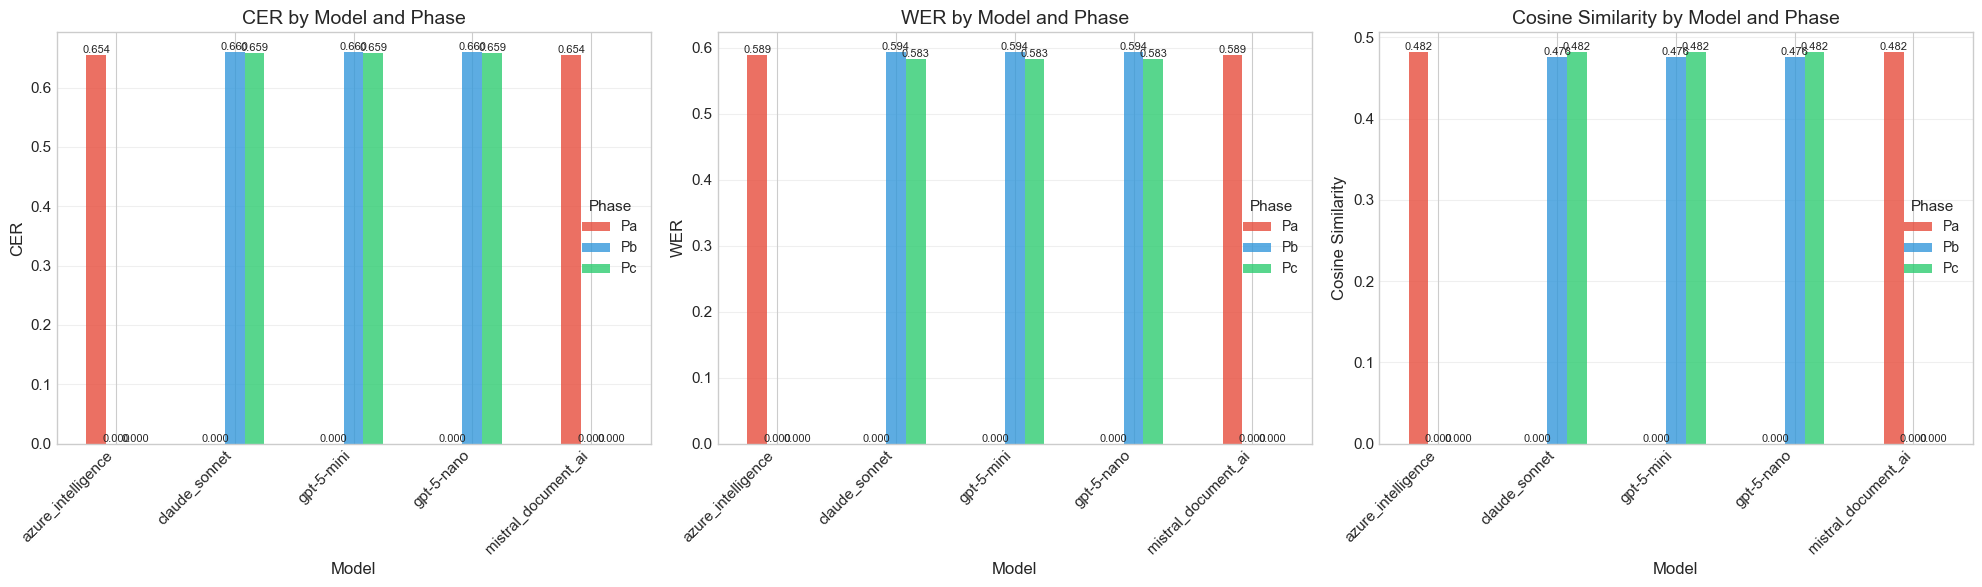

In [45]:
# Bar charts for each metric
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
axes = axes.flatten()

metrics_to_plot = ['CER', 'WER', 'Cosine Similarity']
colors = ['#ff6b6b', '#4ecdc4', '#45b7d1', '#2ecc71', '#f39c12']

for idx, (metric, color) in enumerate(zip(metrics_to_plot, colors)):
    ax = axes[idx]
    
    # Pivot data for grouped bar chart
    pivot_data = summary_df.pivot(index='Model', columns='Phase', values=metric)
    
    pivot_data.plot(kind='bar', ax=ax, color=['#e74c3c', '#3498db', '#2ecc71'], alpha=0.8)
    
    ax.set_title(f'{metric} by Model and Phase', fontsize=14, fontweight='bold')
    ax.set_xlabel('Model', fontsize=12)
    ax.set_ylabel(metric, fontsize=12)
    ax.legend(title='Phase', title_fontsize=11, fontsize=10)
    ax.grid(axis='y', alpha=0.3)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    
    # Add value labels on bars
    for container in ax.containers:
        ax.bar_label(container, fmt='%.3f', fontsize=8)

plt.tight_layout()
plt.show()

### Box Plot Distribution Analysis

In [46]:
# Calculate per-sample metrics for box plots
sample_metrics_data = []

for phase, df in phase_dfs.items():
    pred_cols = [col for col in df.columns if col.startswith('prediction_')]
    
    for pred_col in pred_cols:
        model = pred_col.replace('prediction_', '')
        
        for _, row in df.iterrows():
            metrics = calculate_sample_metrics_with_cosine(row['ground_truth'], row[pred_col], phase, row['sample_id'], model, embedding_manager)
            
            sample_metrics_data.append({
                'Phase': phase,
                'Model': model,
                'CER': metrics['cer'],
                'WER': metrics['wer'],
                # 'ANLS': metrics['anls'],
                'Cosine Similarity': metrics['cosine_similarity'],
                # 'Ground Truth in Prediction': metrics['ground_truth_in_prediction']
            })

sample_metrics_df = pd.DataFrame(sample_metrics_data)

# Create box plots
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
axes = axes.flatten()

for idx, metric in enumerate(['CER', 'WER', 'Cosine Similarity']):
    ax = axes[idx]
    
    # Create box plot
    sns.boxplot(data=sample_metrics_df, x='Model', y=metric, hue='Phase', ax=ax, palette='Set2')
    
    ax.set_title(f'{metric} Distribution', fontsize=14, fontweight='bold')
    ax.set_xlabel('Model', fontsize=12)
    ax.set_ylabel(metric, fontsize=12)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

KeyboardInterrupt: 

### Heatmap: Model vs Metric Performance

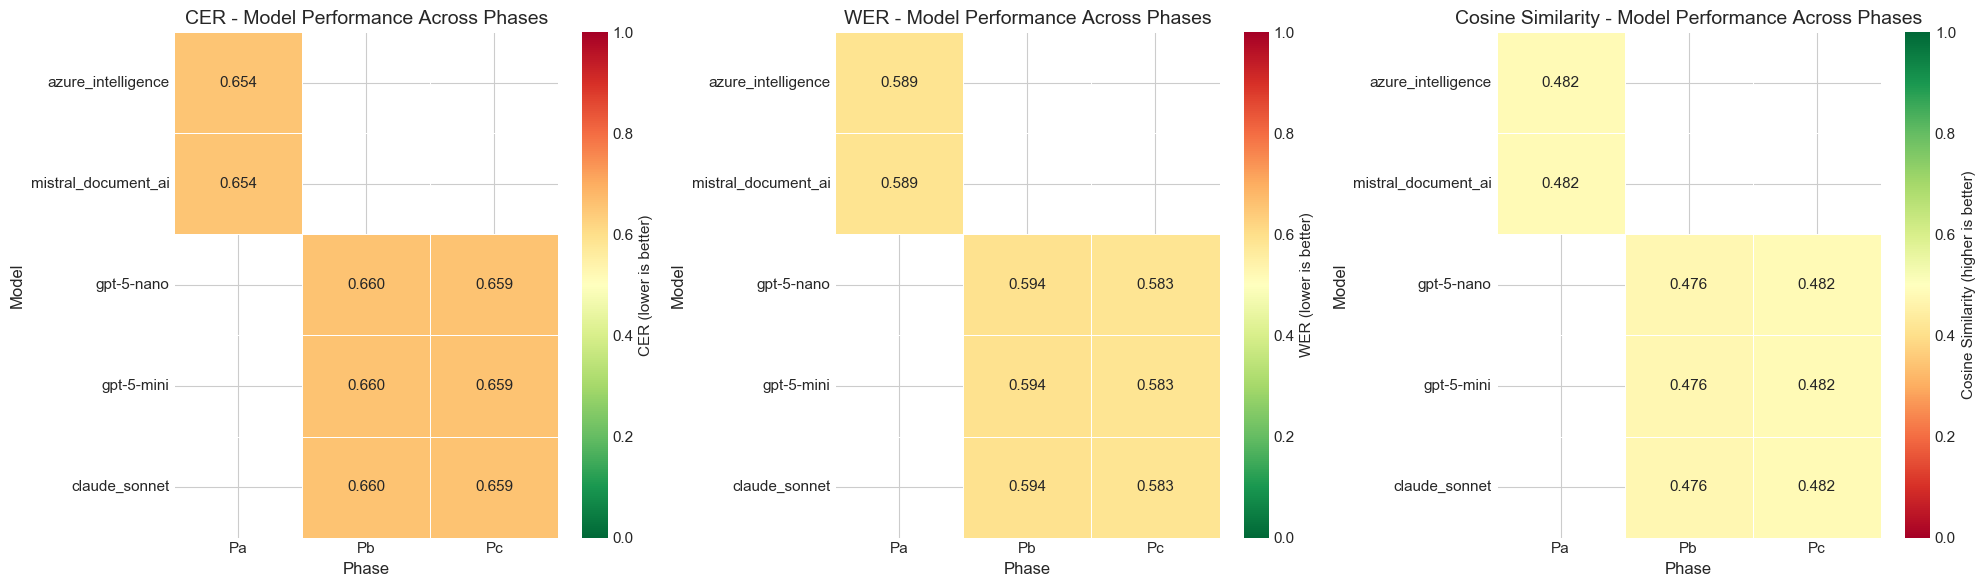

In [47]:
# Create heatmaps for each metric
metrics_to_show = ['CER', 'WER',  'Cosine Similarity']
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
axes = axes.flatten()

for idx, metric_name in enumerate(metrics_to_show):
    ax = axes[idx]
    
    # Create heatmap data: rows = models, columns = phases
    heatmap_data = []
    model_names = []
    phase_names = list(metrics_results.keys())
    
    # Get all unique models across all phases and sort them according to MODEL_ORDER
    all_models = set()
    for phase_models in metrics_results.values():
        all_models.update(phase_models.keys())
    all_models = sort_models(list(all_models))
    
    # Build heatmap data
    for model in all_models:
        row_data = []
        for phase in phase_names:
            if model in metrics_results[phase]:
                # Get the metric value based on metric_name
                if metric_name == 'CER':
                    value = metrics_results[phase][model]['cer']
                elif metric_name == 'WER':
                    value = metrics_results[phase][model]['wer']
                elif metric_name == 'ANLS':
                    value = metrics_results[phase][model]['anls']
                elif metric_name == 'Cosine Similarity':
                    value = metrics_results[phase][model]['cosine_similarity']
                else:
                    value = np.nan
                row_data.append(value)
            else:
                row_data.append(np.nan)
        
        heatmap_data.append(row_data)
        model_names.append(model)
    
    heatmap_df = pd.DataFrame(
        heatmap_data,
        index=model_names,
        columns=phase_names
    )
    
    # Set colormap and label based on metric type
    if metric_name in ['CER', 'WER']:
        # Lower is better for error rates - use reversed colormap (green for low, red for high)
        cmap = 'RdYlGn_r'
        cbar_label = f'{metric_name} (lower is better)'
    else:
        # Higher is better for ANLS and Cosine Similarity - use normal colormap (green for high, red for low)
        cmap = 'RdYlGn'
        cbar_label = f'{metric_name} (higher is better)'
    
    sns.heatmap(heatmap_df, annot=True, fmt='.3f', cmap=cmap, 
                ax=ax, cbar_kws={'label': cbar_label}, 
                vmin=0, vmax=1, linewidths=0.5)
    
    ax.set_title(f'{metric_name} - Model Performance Across Phases', fontsize=14, fontweight='bold')
    ax.set_xlabel('Phase', fontsize=12)
    ax.set_ylabel('Model', fontsize=12)

plt.tight_layout()
plt.show()

### Scatter Plot: CER vs WER Correlation

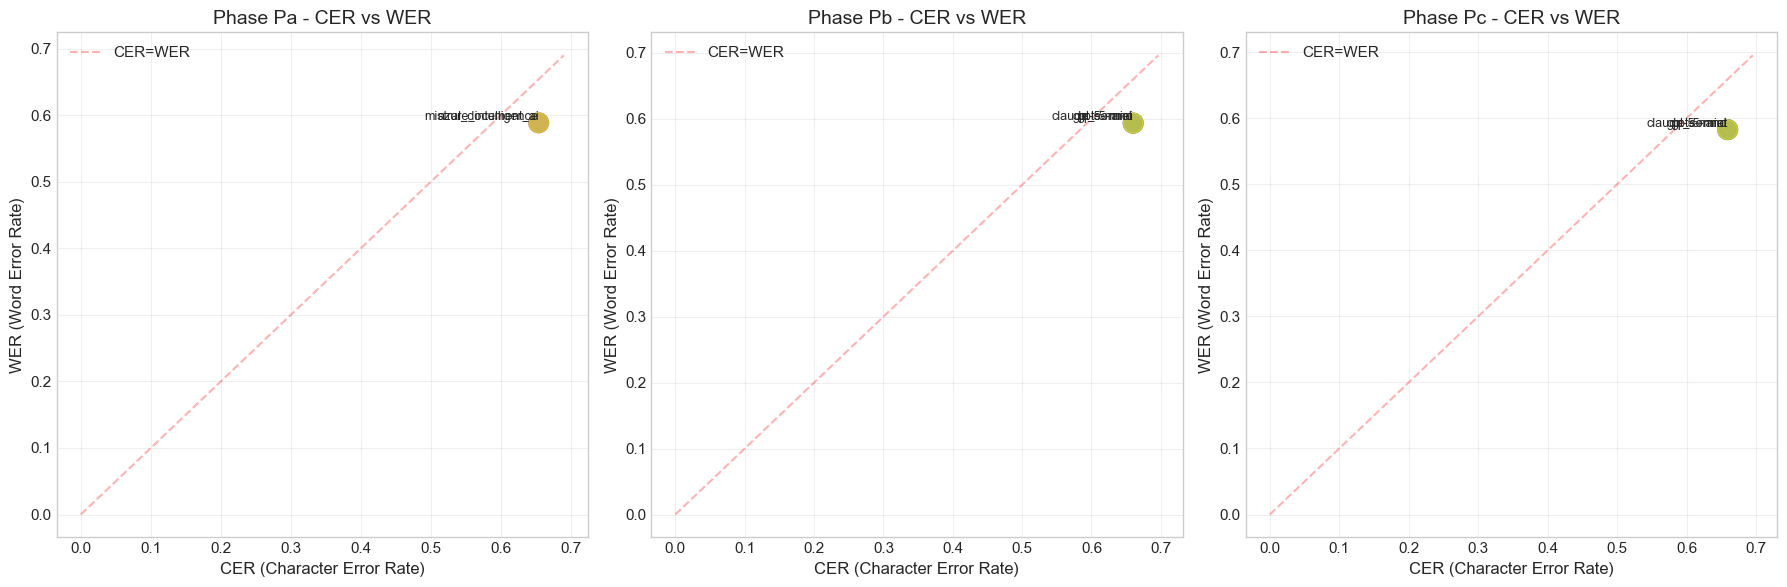

In [48]:
# Scatter plot of CER vs WER for each phase
fig, axes = plt.subplots(1, len(metrics_results), figsize=(6 * len(metrics_results), 6))

if len(metrics_results) == 1:
    axes = [axes]

for idx, phase in enumerate(metrics_results.keys()):
    ax = axes[idx]
    
    phase_data = summary_df[summary_df['Phase'] == phase]
    
    scatter = ax.scatter(phase_data['CER'], phase_data['WER'], 
                        s=200, alpha=0.6, c=range(len(phase_data)), cmap='viridis')
    
    # Add model labels
    for _, row in phase_data.iterrows():
        ax.annotate(row['Model'], (row['CER'], row['WER']), 
                   fontsize=9, ha='right', va='bottom')
    
    ax.set_title(f'Phase {phase} - CER vs WER', fontsize=14, fontweight='bold')
    ax.set_xlabel('CER (Character Error Rate)', fontsize=12)
    ax.set_ylabel('WER (Word Error Rate)', fontsize=12)
    ax.grid(alpha=0.3)
    
    # Add diagonal reference line
    lims = [0, max(ax.get_xlim()[1], ax.get_ylim()[1])]
    ax.plot(lims, lims, 'r--', alpha=0.3, label='CER=WER')
    ax.legend()

plt.tight_layout()
plt.show()

## 5. Error Analysis: Best and Worst Samples

Identify samples where models perform best and worst to understand error patterns.


BEST PERFORMING SAMPLES (Lowest CER) - Model: Mistral Document AI


,Ground Truth,Prediction,CER,WER,Cosine Similarity,Words in GT not in Prediction,Words in Prediction not in GT
1,"€ IMAGERIE Rendez-vous le Lundi 23 Août 2021 à 14H40 pour votre SCANNER THORAX +\nABDOMINO-PELVIEN AVEC INJECTION sur le site 120 Ancienne route de Beaujeu 69400\nARNAS Faire pratiquer par un laboratoire d'analyses médicales : o TAUX DE\nCREATININE de moins de 1 mois (apporter les résultats le jour de l'examen)\nApporter (à commander à la pharmacie 48 heures avant) : o IOMERON 400 : 1\ntrousse AN 100ml (seringue + flacon) CIP : 3400936198005 o A jeun de solide 3h\navant l'examen o Boire 1/2 litre d'eau 30 minutes avant l'examen 0 Vos anciens\nScanner, echographie, IRM .... o La lettre du médecin o Votre carte vitale et un\nmoyen de paiement - o · Si vous êtes pris en charge à 100% au titre d'une ALD,\nd'une invalidité, ou si vous bénéficiez de la CMU : Votre attestation de\nsécurité sociale portant la mention « MEDECIN TRAITANT DECLARE » Un devis vous\nsera remis lors de votre accueil détaillant le montant des honoraires et des\ncompléments d'honoraires. A titre informatif, le montant total de l'examen est\ncompris entre 59€ et 128€, avec des compléments d'honoraires inclus compris\nentre 28.99€ et 39.46€ Les radiologues sont conventionnés secteur II avec\nconvention OPTAM permettant une meilleure prise en charge par votre\ncomplémentaire santé* *Plus d'information sur le site ameli.fr","structure_name: IMAGERIE patient_instruction: Rendez-vous le Lundi 23 Août 2021\nà 14H40 pour votre SCANNER THORAX + ABDOMINO-PELVIEN AVEC INJECTION sur le site\n120 Ancienne route de Beaujeu patient_instruction: 69400 ARNAS other: Faire\npratiquer par un laboratoire d'analyses médicales : TAUX DE CREATININE de moins\nde 1 mois (apporter les résultats le jour de l'examen) Apporter (à commander à\nla pharmacie 48 heures avant) : product_name: IOMERON 400 other: : 1\ncontainer_type: trousse AN container_quantity_inside: 100ml other: (\nvector_type: seringue other: + container_type: flacon other: ) CIP :\n3400936198005 patient_instruction: A jeun de solide 3h avant l'examen Boire 1/2\nlitre d'eau 30 minutes avant l'examen other: Vos anciens Scanner, échographie,\nIRM La lettre du médecin Votre carte vitale et un moyen de paiement Si vous êtes\npris en charge à 100% au titre d'une ALD, d'une invalidité, ou si vous\nbénéficiez de la CMU : Votre attestation de sécurité sociale portant la mention\nMEDECIN TRAITANT DECLARE Un devis vous sera remis lors de votre accueil\ndétaillant le montant des honoraires et des compléments d'honoraires. A titre\ninformatif, le montant total de l'examen est compris entre 59€ et 128€, avec des\ncompléments d'honoraires inclus compris entre 28.99€ et 39.46€ Les radiologues\nsont conventionnés secteur II avec convention OPTAM permettant une meilleure\nprise en charge par votre complémentaire santé* *Plus d'information sur le site\nameli.fr",0.1649,0.1351,0.6050,"[(seringue, ...., o, 0, ·, », echographie,, -, flacon), €, «]","[), other:, structure_name:, container_type:, seringue, patient_instruction:, (, vector_type:, flacon, échographie,, product_name:, container_quantity_inside:]"
26,"Infirmerie ORDONNANCE Veuillez commander (48H à l'avance) en pharmacie et\napporter le jour de votre examen : · 1 trousse Scanner EXP de IOPAMIRON 370 en\n100ml (code CIP : 34009 30148730) . Vous pouvez manger léger. · Apporter le jour\nde l'examen : -la prescription de l'examen. -vos examens médicaux antérieurs.\n-votre carte vitale, votre attestation de droit (CMU, ALD ... ) -un moyen de\npaiement si vous n'êtes pas à 100%. IMPORTANT : PREVENEZ EN CAS D'ALLERGIE OU DE\nDIABETE - Validation électronique","structure_name: Infirmerie exoneration: ORDONNANCE other: Veuillez commander\n(48H à l'avance) en pharmacie et apporter le jour de votre examen :\ncontainer_quantity_inside: 1 vector_type: trousse Scanner EXP other: de\nproduct_name: IOPAMIRON 370 other: en vector_quantity_inside: 100ml other: (code\nCIP : product_name: 340


WORST PERFORMING SAMPLES (Highest CER) - Model: Mistral Document AI


,Ground Truth,Prediction,CER,WER,Cosine Similarity,Words in GT not in Prediction,Words in Prediction not in GT
91,CHIRURGIE GYNECOLOGIQUE -OBSTETRIQUE Tardyferon 80: 1/j pdt 2 mois - -,structure_name: POLYCLINIQUE DU BEAUJOLAIS other: Docteur firstname: Ghani\nlastname: ZIANE address: 120 Ancienne route de Beaujeu - ARNAS other: Ancien\nInterne des Hôpitaux de STRASBOURG address: BP 71 other: Ancien Assistant Chef\nde Clinique des Hôpitaux de Lyon address: 69653 VILLEFRANCHE CEDEX other: - Tél.\nphone: 0811 657 658 speciality: CHIRURGIE GYNECOLOGIQUE -OBSTETRIQUE\nstructure_name: Cabinet other: Tél.: phone: 04 74 65 66 06 adeli: 69 1 70663 4\nphone: 04 74 65 67 14 other: RPPS rpps: 1 000 51 74 940 phone: 04.74.65.71.50\nother: Fax fax: 04 74 65 66 65 product_name: Tardyferon 80 other: :\ntiming_frequency: 1 other: / timing_period_unit: j other: pdt bounds_duration: 2\nbounds_duration_unit: mois other: Docteur lastname: ZIANE,0.9086,0.9381,0.4313,"[1/j, 80:]","[timing_frequency:, 0811, 04.74.65.71.50, bounds_duration_unit:, ZIANE, Ancienne, 4, 70663, 65, /, Tél.:, 51, Interne, phone:, RPPS, 940, Beaujeu, 14, fax:, 06, 67, j, structure_name:, speciality:, route, 000, ARNAS, STRASBOURG, product_name:, 04, des, 69, 657, Cabinet, 1, POLYCLINIQUE, CEDEX, Fax, Ghani, address:, lastname:, Hôpitaux, timing_period_unit:, rpps:, 658, Ancien, DU, 74, 80, firstname:, adeli:, Clinique, 66, Lyon, Chef, BEAUJOLAIS, BP, other:, 71, 120, :, Tél., de, Assistant, Docteur, bounds_duration:, 69653, VILLEFRANCHE]"
149,"POLE URGENCES ORDONNANCE Villefranche, le 23/11/2019 : ALD : Non"" Ordonnance\nentièrement substituable sauf mention particulière. Compresses stériles\nhumidifier avec de l'eau tiède et masser vers l'extérieur pendant environ 5\nminutes PICLOXYDINE DICHLORHYDRATE (VITABACT) 0,05% collyre sol : 1 goutte 2 à 6\nfois par jour, pendant 1 semaine. En cas de problème, reconsulter un médecin","structure_name: InOpital NORD OUEST address: VRLEFRANCHE-SUR-SAÓNE other: FINESS\nJURIDIQUE finess: 69 0782 222 other: FINESS GEOGRAPHIQUE : finess: 69 0000 575\nstructure_name: POLE URGENCES other: ORDONNANCE Dr firstname: Frédéric lastname:\nVERBOIS rpps: 10003107116 location: Villefranche other: , le\ndate_of_prescription: 23/11/2019 other: Responsable de Pôle Dr firstname: Marc\nlastname: DU BESSET rpps: 10100030500 other: Responsable SMUR Dr firstname:\nChristelle lastname: PIDOUX rpps: 10100456630 exoneration: ALD : Non other:\nResponsable UH.C D. Dr firstname: Sandra lastname: DENISOFF rpps: 10100066967\nother: Responsable U.P.U Dr firstname: Elodie lastname: JOETS rpps: 10001616589\nother: Responsable USN1 Dr firstname: Bastien lastname: ANETTE rpps: 10100054278\nother: Dr firstname: Julie lastname: ARTAUD rpps: 10101263704 other: Dr\nfirstname: Guillaume lastname: AUBOURG rpps: 10100949634 other: Dr firstname:\nAnne lastname: CHANCRIN rpps: 10100386282 other: Ordonnance entièrement\nsubstituable sauf mention particulière. Dr firstname: Olivier lastname: CHEREAU\nrpps: 10101745684 other: Dr firstname: Vincent lastname: DANBAKLI other: Dr\nfirstname: Claire lastname: DE LA SALLE rpps: 10100864478 other: Dr firstname:\nGuillaume lastname: DURAND rpps: 10100677870 other: Dr firstname: Eda lastname:\nERTUGRUL rpps: 10100538999 other: Dr firstname: Florence lastname: GAILLARD\nrpps: 10004023064 other: Dr firstname: Mathilde lastname: GENTY rpps:\n10100751162 product_name: Compresses stériles patient_instruction: humidifier\navec de l'eau tiède et masser vers l'extérieur other: Dr firstname: Nadège\nlastname: HINAUX rpps: 10100318053 other: Dr firstname: Mylène lastname: ISOUARD\nrpps: 10100315547 other: pendant environ timing_event_duration: 5 minutes other:\nDr firstname: Marie lastname: LANGEVIN rpps: 10101099843 product_name:\nPICLOXYDINE DICHLORHYDRATE other: ( product_name: VITABACT other: ) dosing:\n0,05% form: collyre sol other: : dose_quantity_low: 1 dose_unit: goutte other:\nDr firstname: Marie-Elise lastname: LHUILLIER rpps: 10101164852 ot


BEST PERFORMING SAMPLES (Highest Cosine Similarity) - Model: Mistral Document AI


,Ground Truth,Prediction,CER,WER,Cosine Similarity,Words in GT not in Prediction,Words in Prediction not in GT
55,DIENOGEST 2 mg cp (SAWIS) Quantité suffisante pour 3 mois HAUPT: NY 1 1/1,product_name: DIENOGEST dosing: 2 mg form: cp product_name: (SAWIS) other:\nQuantité suffisante pour bounds_duration: 3 bounds_duration_unit: mois other:\nHAUN specialty_cardinality: 1 other: 1/1,0.6580,0.4783,0.7920,"[HAUPT:, NY]","[other:, HAUN, bounds_duration_unit:, bounds_duration:, product_name:, dosing:, specialty_cardinality:, form:]"
9,"Cabinet Médical Ancien Assistant des Hôpitaux LIMAS, le 23/08/2021 -\nbétaméthasone (dipropionate) * 5 mg/ml + bétaméthasone (phosphate disodique) * 2\nmg/ml ; voie parentérale ; susp inj (1 boîte) (DIPROSTENE Susp inj 1Ser\npréremplie) pour. infiltration","structure_name: Cabinet Médical other: Ancien Assistant des Hôpitaux location:\nLIMAS, other: le date_of_prescription: 23/08/2021 other: - product_name:\nbétaméthasone (dipropionate) other: * dosing: 5 mg/ml other: + product_name:\nbétaméthasone (phosphate disodique) other: * dosing: 2 mg/ml other: ; route:\nvoie parentérale other: ; form: susp administration_method: inj other: (\ncontainer_cardinality: 1 container_type: boîte other: ) ( product_name:\nDIPROSTENE form: Susp administration_method: inj vector_quantity_inside: 1\nvector_type: Ser préremplie other: ) pour administration_method: infiltration",0.5871,0.5634,0.7289,"[boîte), (1, pour., préremplie), 1Ser, (DIPROSTENE]","[pour, vector_type:, date_of_prescription:, form:, route:, boîte, préremplie, other:, structure_name:, administration_method:, Ser, container_cardinality:, location:, (, dosing:, DIPROSTENE, product_name:, container_type:, ), 1, vector_quantity_inside:]"
25,"Lyon le 01/09/2021 Poids: 59,0 Kg Prescriptions relatives au traitement de\nl'affection de longue durée reconnue (AFFECTION EXONERANTE) ZOLPIDEM 10mg:\n0.0.0.1 1 mois OP2324050010 --- 1","other: Lyon le date_of_prescription: 01/09/2021 other: Poids: weight: 59,0\nother: Kg exoneration: Prescriptions relatives au traitement de l'affection de\nlongue durée reconnue (AFFECTION EXONERANTE) product_name: ZOLPIDEM dosing: 10mg\nother: : timing_when: 0.0.0. other: 1 bounds_duration: 1 bounds_duration_unit:\nmois",0.4937,0.4737,0.7271,"[0.0.0.1, ---, OP2324050010, 10mg:]","[other:, timing_when:, bounds_duration_unit:, bounds_duration:, exoneration:, 10mg, dosing:, date_of_prescription:, 0.0.0., product_name:, :, weight:]"
16,"Pneumologie Cancérologie Thoracique ORDONNANCE SYMBICORT une inhalation 400\nmatin et soir OAR : 4 mois QSP : Médicaments substituables sauf mention\ncontraire "" L'hôpital Nord-Ouest s'engage pour la dématérialisation des\ncourriers médicaux. Pour toute information. merci de contacter assistance@\nsante-ra.fr ""","speciality: Pneumologie Cancérologie Thoracique other: ORDONNANCE product_name:\nSYMBICORT dose_quantity_low: une dose_unit: inhalation 400 timing_when: matin\nother: et timing_when: soir other: OAR : 4 bounds_duration_unit: mois other: QSP\n: Médicaments substituables sauf mention contraire L'hôpitol Nord-Ques: s'engage\npour la dématérialisation des courriers médicaux. Pour foute information merci\nde contacter assistance@sante-ro.fr """,0.3326,0.3600,0.7075,"[Nord-Ouest, assistance@, sante-ra.fr, toute, L'hôpital, information.]","[other:, timing_when:, bounds_duration_unit:, speciality:, dose_unit:, dose_quantity_low:, Nord-Ques:, assistance@sante-ro.fr, L'hôpitol, information, foute, product_name:]"
7,"- = LYON CEDEX 04, le 30/07/2021 Prescription relatives au traitement de\nl'affection de longue durée reconnue (liste ou hors liste) (AFFECTION\nEXONÉRANTE) ACTISORB 10.5 x 105 cm: 2 Compresses /jour Qté à réévaluer, OAR : 3\nmois Prescription SANS RAPPORT avec l'affection de longue durée (MALADIES\nINTERCURRENTES) I.F 1 til . r Date : 30/07/2021","location: LYON CEDEX 04, other: le date_of_prescription: 30/07/2021 exoneration:\nPrescription relatives au traitement de l'affection de longue dur


WORST PERFORMING SAMPLES (Lowest Cosine Similarity) - Model: Mistral Document AI


,Ground Truth,Prediction,CER,WER,Cosine Similarity,Words in GT not in Prediction,Words in Prediction not in GT
94,"Prescriptions relatives au traitement de l'affection de longue durée reconnue\n(liste ou hors liste) (AFFECTION EXONÉRANTE) Procoralan 7,5 mg: Non substituala\n1 comprimé matin et soir Atacand 16 mg: ren susitifia22 090 le 13/05 1 comprimé\nle matin 5 Doliprane 500: 2 à 6 gelules par jour (NE PAS DEPASSER 3 grammes/j de\nParacetamol) - Inexium 20 mg: 1 comprimé le matin de my Laroxyl 40 mg/ml: Non\nSubstituazle 20 gouttes le soir 2/ Lasilix 40 mg: Non substitualle 1 comprimé le\nmatin Prescriptions SANS RAPPORT avec l'affection de longue durée (MALADIES\nINTERCURRENTES) 2 Ceris 20 mg: 1 comprimé matin et soir Non SubstituaBle /\nDaflon 500: 1 comprimé matin et soir un Avamys: 2 pulv/narine/j with\nColpotrophine: 1 tube - Transulose: 1 à 3 cuillères à café par jour An Luz\nstclaire OAR 3 mois - Maladies des Bronches et des Poumons - Maladies\nAllergiques Respiratoires - Consultations Anti-Tabac Membre d'une association de\ngestion, le règlement par chèque est accepté.","structure_name: SELARL CENTRE MEDICAL DE PNEUMOLOGIE ET D'ALLERGOLOGIE\nRESPIRATOIRE DE CALUIRE other: Secrétariat ouvert de 9H00 à 13h00 et de 14H00 à\n18H00 address: 42, Rue Jean Moulin other: Tél : phone: 04 78 23 43 75 address:\n69300 CALUIRE other: Docteur firstname: Gérard lastname: CHATTÉ other: Ancien\nInterne des Hôpitaux de Lyon Ancien Assistant des Hôpitaux de Lyon Chef de\nClinique à la Faculté Consultant au Centre Léon Bérard adeli: 69 I 70469 6\nother: Docteur firstname: Michel lastname: COLAS other: Docteur firstname:\nMarie-Noëlle lastname: LIEGEON other: Docteur firstname: Louise lastname: GINDRE\nexoneration: Prescriptions relatives au traitement de l'affection de longue\ndurée reconnue (liste ou hors liste) (AFFECTION EXONÉRANTE) product_name:\nProcoralan dosing: 7,5 other: mg: substitution: Non substituous product_name:\nAtacand dose_quantity_low: 1 dosing: 16 other: mg: substitution: in other: W\nsubstitution: hittheir other: D9 be 13 los dose_unit: comprimé timing_when:\nmatin other: et timing_when: soir dose_quantity_low: 1 dose_unit: comprimé\nother: le timing_when: matin product_name: Doliprane 500 other: : substitution:\nNor swastic-33 timing_frequency: 2 other: à timing_frequency_max: 6 dose_unit:\ngelules other: par timing_period_unit: jour other: (NE PAS DEPASSER\ndose_quantity_low: 3 dose_unit: grammes other: / timing_period_unit: ] other: de\nproduct_name: Paracetam other: ol) - product_name: Inexium dosing: 20 mg other:\n: substitution: for substance other: mon product_name: Laroxyl dosing: 40 mg/\nother: ml: substitution: for substitute dose_quantity_low: 1 dose_unit: comprimé\nother: le timing_when: matin other: 21 product_name: Lasilix dosing: 40 other:\nmg: substitution: Non sussitive dose_quantity_low: 20 dose_unit: gouttes other:\nle timing_when: soir dose_quantity_low: 1 dose_unit: comprimé other: le\ntiming_when: matin exoneration: Prescriptions SANS RAPPORT avec l'affection de\nlongue durée (MALADIES INTERCURRENTES) other: 2 product_name: Ceris dosing: 20\nmg other: : timing_frequency: 1 dose_unit: comprimé timing_when: matin soir\nsubstitution: for sussitualle other: et product_name: Daflon 500 other: :\ndose_quantity_low: 1 dose_unit: comprimé timing_when: matin other: et\ntiming_when: soir other: non product_name: Avamys other: : timing_frequency: 2\nother: pulv/narine/ timing_period_unit: j other: with product_name: Transulose\nother: : product_name: Colpotrophine other: : timing_period_unit: jour\nsubstitution: non 203.states container_cardinality: 1 container_type: tube\nsubstitution: Ner switchers timing_frequency: 1 other: à timing_frequency_max: 3\ndose_unit: cuillères à café other: par OAR bounds_duration: 3\nbounds_duration_unit: mois structure_name: SELARL Centre P.A. other: Doctour\nfirstname: Gorard lastname: CHAIRE other: 691 704691 address: 42, rue Jean N°\nounn - other: Tél. phone: 04 78 23 4


BAG OF WORDS ANALYSIS - Common Error Patterns (Mistral Document AI)


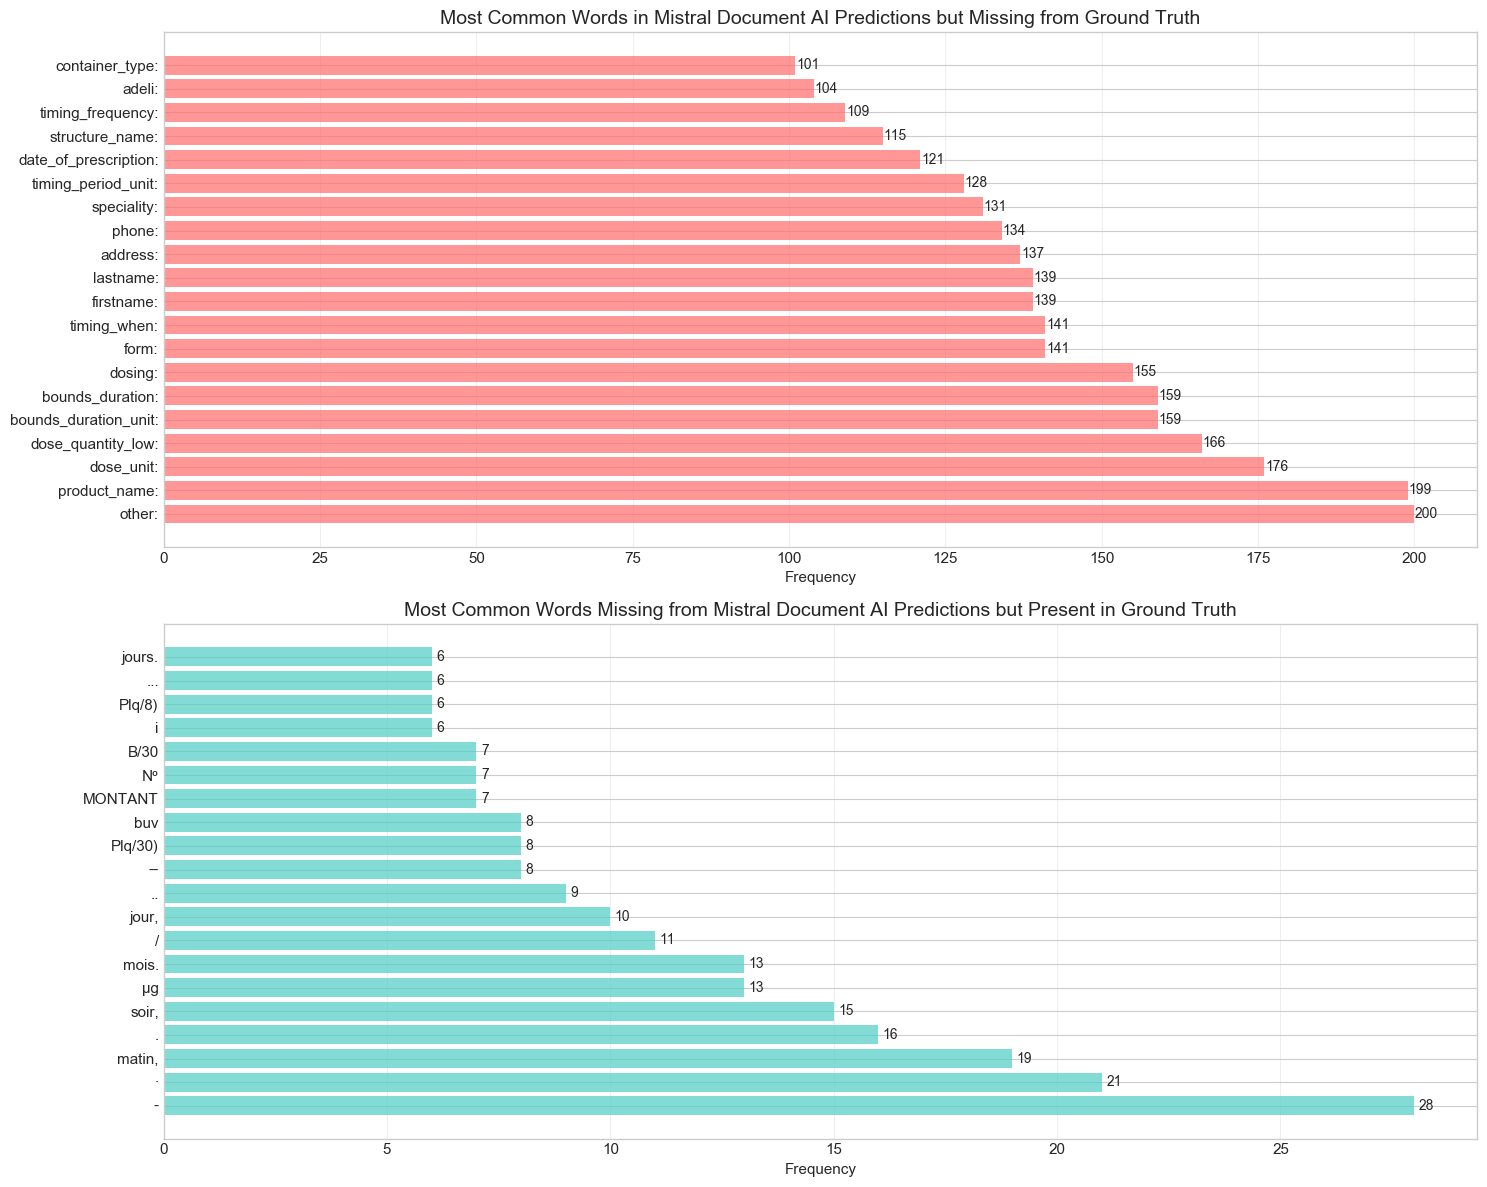


Error Pattern Summary for Mistral Document AI:
Total unique words in predictions but not in ground truth: 3243
Total unique words in ground truth but not in predictions: 1367
Total erroneous words in predictions: 11939
Total missing words from predictions: 1881

Top 5 words added incorrectly: other: (200), product_name: (199), dose_unit: (176), dose_quantity_low: (166), bounds_duration_unit: (159)
Top 5 words most frequently missed: - (28), · (21), matin, (19), . (16), soir, (15)


In [49]:
import textwrap
import difflib

# Analyze best and worst performing samples for Pa phase - Mistral Document AI
if 'Pa' in phase_dfs:
    df_analysis = phase_dfs['Pa'].copy()
    
    # Use Mistral Document AI for analysis
    first_model = 'mistral_document_ai'
    
    # Function to find differences between texts
    def find_text_differences(gt_text, pred_text):
        """Find words in ground truth not in prediction and vice versa."""
        if pd.isna(gt_text) or pd.isna(pred_text):
            return [], []
        
        # Split texts into words (simple whitespace split)
        gt_words = set(str(gt_text).split())
        pred_words = set(str(pred_text).split())
        
        # Find differences
        gt_not_in_pred = list(gt_words - pred_words)
        pred_not_in_gt = list(pred_words - gt_words)
        
        return gt_not_in_pred, pred_not_in_gt
    
    # Calculate CER, WER, and Cosine Similarity for each sample
    df_analysis['cer'] = df_analysis.apply(
        lambda row: calculate_cer(row['ground_truth'], row[f'prediction_{first_model}']),
        axis=1
    )
    df_analysis['wer'] = df_analysis.apply(
        lambda row: calculate_wer(row['ground_truth'], row[f'prediction_{first_model}']),
        axis=1
    )
    df_analysis['cosine_similarity'] = df_analysis.apply(
        lambda row: calculate_sample_metrics_with_cosine(
            row['ground_truth'], 
            row[f'prediction_{first_model}'], 
            'Pa', 
            row['sample_id'], 
            first_model, 
            embedding_manager
        )['cosine_similarity'],
        axis=1
    )
    
    # Calculate text differences for each sample
    df_analysis['gt_not_in_pred'], df_analysis['pred_not_in_gt'] = zip(*df_analysis.apply(
        lambda row: find_text_differences(row['ground_truth'], row[f'prediction_{first_model}']),
        axis=1
    ))
    
    # Get best and worst samples by CER
    best_samples_cer = df_analysis.nsmallest(5, 'cer')
    worst_samples_cer = df_analysis.nlargest(5, 'cer')
    
    # Get best and worst samples by Cosine Similarity
    best_samples_cosine = df_analysis.nlargest(5, 'cosine_similarity')
    worst_samples_cosine = df_analysis.nsmallest(5, 'cosine_similarity')
    
    # Set display options for full text and wrapping
    pd.set_option('display.max_colwidth', None)
    pd.set_option('display.width', None)
    
    # Function to wrap text
    def wrap_text(text, width=80):
        if pd.isna(text):
            return ""
        return textwrap.fill(str(text), width=width)
    
    # Create DataFrames for CER-based analysis
    best_df_cer = pd.DataFrame({
        'Ground Truth': best_samples_cer['ground_truth'].apply(lambda x: wrap_text(x)),
        'Prediction': best_samples_cer[f'prediction_{first_model}'].apply(lambda x: wrap_text(x)),
        'CER': best_samples_cer['cer'].round(4),
        'WER': best_samples_cer['wer'].round(4),
        'Cosine Similarity': best_samples_cer['cosine_similarity'].round(4),
        'Words in GT not in Prediction': best_samples_cer['gt_not_in_pred'],
        'Words in Prediction not in GT': best_samples_cer['pred_not_in_gt']
    })
    
    worst_df_cer = pd.DataFrame({
        'Ground Truth': worst_samples_cer['ground_truth'].apply(lambda x: wrap_text(x)),
        'Prediction': worst_samples_cer[f'prediction_{first_model}'].apply(lambda x: wrap_text(x)),
        'CER': worst_samples_cer['cer'].round(4),
        'WER': worst_samples_cer['wer'].round(4),
        'Cosine Similarity': worst_samples_cer['cosine_similarity'].round(4),
        'Words in GT not in Prediction': worst_samples_cer['gt_not_in_pred'],
        'Words in Prediction not in GT': worst_samples_cer['pred_not_in_gt']
    })
    
    # Create DataFrames for Cosine Similarity-based analysis
    best_df_cosine = pd.DataFrame({
        'Ground Truth': best_samples_cosine['ground_truth'].apply(lambda x: wrap_text(x)),
        'Prediction': best_samples_cosine[f'prediction_{first_model}'].apply(lambda x: wrap_text(x)),
        'CER': best_samples_cosine['cer'].round(4),
        'WER': best_samples_cosine['wer'].round(4),
        'Cosine Similarity': best_samples_cosine['cosine_similarity'].round(4),
        'Words in GT not in Prediction': best_samples_cosine['gt_not_in_pred'],
        'Words in Prediction not in GT': best_samples_cosine['pred_not_in_gt']
    })
    
    worst_df_cosine = pd.DataFrame({
        'Ground Truth': worst_samples_cosine['ground_truth'].apply(lambda x: wrap_text(x)),
        'Prediction': worst_samples_cosine[f'prediction_{first_model}'].apply(lambda x: wrap_text(x)),
        'CER': worst_samples_cosine['cer'].round(4),
        'WER': worst_samples_cosine['wer'].round(4),
        'Cosine Similarity': worst_samples_cosine['cosine_similarity'].round(4),
        'Words in GT not in Prediction': worst_samples_cosine['gt_not_in_pred'],
        'Words in Prediction not in GT': worst_samples_cosine['pred_not_in_gt']
    })
    
    print("\n" + "="*120)
    print(f"BEST PERFORMING SAMPLES (Lowest CER) - Model: {get_model_display_name(first_model)}")
    print("="*120)
    display(best_df_cer)
    
    print("\n" + "="*120)
    print(f"WORST PERFORMING SAMPLES (Highest CER) - Model: {get_model_display_name(first_model)}")
    print("="*120)
    display(worst_df_cer)
    
    print("\n" + "="*120)
    print(f"BEST PERFORMING SAMPLES (Highest Cosine Similarity) - Model: {get_model_display_name(first_model)}")
    print("="*120)
    display(best_df_cosine)
    
    print("\n" + "="*120)
    print(f"WORST PERFORMING SAMPLES (Lowest Cosine Similarity) - Model: {get_model_display_name(first_model)}")
    print("="*120)
    display(worst_df_cosine)

# Bag of Words Analysis for Error Patterns - Mistral Document AI
print("\n" + "="*120)
print("BAG OF WORDS ANALYSIS - Common Error Patterns (Mistral Document AI)")
print("="*120)

from collections import Counter
import matplotlib.pyplot as plt

# Collect all erroneous words from all samples
all_pred_not_in_gt = []
all_gt_not_in_pred = []

for _, row in df_analysis.iterrows():
    all_pred_not_in_gt.extend(row['pred_not_in_gt'])
    all_gt_not_in_pred.extend(row['gt_not_in_pred'])

# Count frequencies
pred_error_counts = Counter(all_pred_not_in_gt)
gt_error_counts = Counter(all_gt_not_in_pred)

# Get top 20 most common errors for each category
top_pred_errors = pred_error_counts.most_common(20)
top_gt_errors = gt_error_counts.most_common(20)

# Create figure with two subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 12))

# Plot 1: Words in Prediction not in Ground Truth
if top_pred_errors:
    words, counts = zip(*top_pred_errors)
    bars1 = ax1.barh(range(len(words)), counts, color='#ff6b6b', alpha=0.7)
    ax1.set_yticks(range(len(words)))
    ax1.set_yticklabels(words)
    ax1.set_xlabel('Frequency')
    ax1.set_title(f'Most Common Words in {get_model_display_name(first_model)} Predictions but Missing from Ground Truth', fontsize=14, fontweight='bold')
    ax1.grid(axis='x', alpha=0.3)
    
    # Add value labels on bars
    for i, (word, count) in enumerate(top_pred_errors):
        ax1.text(count + 0.1, i, f'{count}', va='center', fontsize=10)
else:
    ax1.text(0.5, 0.5, 'No prediction errors found', ha='center', va='center', transform=ax1.transAxes)
    ax1.set_title(f'Words in {get_model_display_name(first_model)} Predictions but Missing from Ground Truth', fontsize=14, fontweight='bold')

# Plot 2: Words in Ground Truth not in Prediction
if top_gt_errors:
    words, counts = zip(*top_gt_errors)
    bars2 = ax2.barh(range(len(words)), counts, color='#4ecdc4', alpha=0.7)
    ax2.set_yticks(range(len(words)))
    ax2.set_yticklabels(words)
    ax2.set_xlabel('Frequency')
    ax2.set_title(f'Most Common Words Missing from {get_model_display_name(first_model)} Predictions but Present in Ground Truth', fontsize=14, fontweight='bold')
    ax2.grid(axis='x', alpha=0.3)
    
    # Add value labels on bars
    for i, (word, count) in enumerate(top_gt_errors):
        ax2.text(count + 0.1, i, f'{count}', va='center', fontsize=10)
else:
    ax2.text(0.5, 0.5, 'No ground truth omissions found', ha='center', va='center', transform=ax2.transAxes)
    ax2.set_title(f'Words Missing from {get_model_display_name(first_model)} Predictions but Present in Ground Truth', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# Print summary statistics
print(f"\nError Pattern Summary for {get_model_display_name(first_model)}:")
print(f"Total unique words in predictions but not in ground truth: {len(pred_error_counts)}")
print(f"Total unique words in ground truth but not in predictions: {len(gt_error_counts)}")
print(f"Total erroneous words in predictions: {sum(pred_error_counts.values())}")
print(f"Total missing words from predictions: {sum(gt_error_counts.values())}")

if top_pred_errors:
    print(f"\nTop 5 words added incorrectly: {', '.join([f'{word} ({count})' for word, count in top_pred_errors[:5]])}")

if top_gt_errors:
    print(f"Top 5 words most frequently missed: {', '.join([f'{word} ({count})' for word, count in top_gt_errors[:5]])}")


BEST PERFORMING SAMPLES (Lowest CER) - Model: azure_intelligence


,Ground Truth,Prediction,CER,WER,Cosine Similarity,Words in GT not in Prediction,Words in Prediction not in GT
1,"€ IMAGERIE Rendez-vous le Lundi 23 Août 2021 à 14H40 pour votre SCANNER THORAX +\nABDOMINO-PELVIEN AVEC INJECTION sur le site 120 Ancienne route de Beaujeu 69400\nARNAS Faire pratiquer par un laboratoire d'analyses médicales : o TAUX DE\nCREATININE de moins de 1 mois (apporter les résultats le jour de l'examen)\nApporter (à commander à la pharmacie 48 heures avant) : o IOMERON 400 : 1\ntrousse AN 100ml (seringue + flacon) CIP : 3400936198005 o A jeun de solide 3h\navant l'examen o Boire 1/2 litre d'eau 30 minutes avant l'examen 0 Vos anciens\nScanner, echographie, IRM .... o La lettre du médecin o Votre carte vitale et un\nmoyen de paiement - o · Si vous êtes pris en charge à 100% au titre d'une ALD,\nd'une invalidité, ou si vous bénéficiez de la CMU : Votre attestation de\nsécurité sociale portant la mention « MEDECIN TRAITANT DECLARE » Un devis vous\nsera remis lors de votre accueil détaillant le montant des honoraires et des\ncompléments d'honoraires. A titre informatif, le montant total de l'examen est\ncompris entre 59€ et 128€, avec des compléments d'honoraires inclus compris\nentre 28.99€ et 39.46€ Les radiologues sont conventionnés secteur II avec\nconvention OPTAM permettant une meilleure prise en charge par votre\ncomplémentaire santé* *Plus d'information sur le site ameli.fr","structure_name: IMAGERIE patient_instruction: Rendez-vous le Lundi 23 Août 2021\nà 14H40 pour votre SCANNER THORAX + ABDOMINO-PELVIEN AVEC INJECTION sur le site\n120 Ancienne route de Beaujeu patient_instruction: 69400 ARNAS other: Faire\npratiquer par un laboratoire d'analyses médicales : TAUX DE CREATININE de moins\nde 1 mois (apporter les résultats le jour de l'examen) Apporter (à commander à\nla pharmacie 48 heures avant) : product_name: IOMERON 400 other: : 1\ncontainer_type: trousse AN container_quantity_inside: 100ml other: (\nvector_type: seringue other: + container_type: flacon other: ) CIP :\n3400936198005 patient_instruction: A jeun de solide 3h avant l'examen Boire 1/2\nlitre d'eau 30 minutes avant l'examen other: Vos anciens Scanner, échographie,\nIRM La lettre du médecin Votre carte vitale et un moyen de paiement Si vous êtes\npris en charge à 100% au titre d'une ALD, d'une invalidité, ou si vous\nbénéficiez de la CMU : Votre attestation de sécurité sociale portant la mention\nMEDECIN TRAITANT DECLARE Un devis vous sera remis lors de votre accueil\ndétaillant le montant des honoraires et des compléments d'honoraires. A titre\ninformatif, le montant total de l'examen est compris entre 59€ et 128€, avec des\ncompléments d'honoraires inclus compris entre 28.99€ et 39.46€ Les radiologues\nsont conventionnés secteur II avec convention OPTAM permettant une meilleure\nprise en charge par votre complémentaire santé* *Plus d'information sur le site\nameli.fr",0.1649,0.1351,0.6050,"[(seringue, ...., o, 0, ·, », echographie,, -, flacon), €, «]","[), other:, structure_name:, container_type:, seringue, patient_instruction:, (, vector_type:, flacon, échographie,, product_name:, container_quantity_inside:]"
26,"Infirmerie ORDONNANCE Veuillez commander (48H à l'avance) en pharmacie et\napporter le jour de votre examen : · 1 trousse Scanner EXP de IOPAMIRON 370 en\n100ml (code CIP : 34009 30148730) . Vous pouvez manger léger. · Apporter le jour\nde l'examen : -la prescription de l'examen. -vos examens médicaux antérieurs.\n-votre carte vitale, votre attestation de droit (CMU, ALD ... ) -un moyen de\npaiement si vous n'êtes pas à 100%. IMPORTANT : PREVENEZ EN CAS D'ALLERGIE OU DE\nDIABETE - Validation électronique","structure_name: Infirmerie exoneration: ORDONNANCE other: Veuillez commander\n(48H à l'avance) en pharmacie et apporter le jour de votre examen :\ncontainer_quantity_inside: 1 vector_type: trousse Scanner EXP other: de\nproduct_name: IOPAMIRON 370 other: en vector_quantity_inside: 100ml other: (code\nCIP : product_name: 340


WORST PERFORMING SAMPLES (Highest CER) - Model: azure_intelligence


,Ground Truth,Prediction,CER,WER,Cosine Similarity,Words in GT not in Prediction,Words in Prediction not in GT
91,CHIRURGIE GYNECOLOGIQUE -OBSTETRIQUE Tardyferon 80: 1/j pdt 2 mois - -,structure_name: POLYCLINIQUE DU BEAUJOLAIS other: Docteur firstname: Ghani\nlastname: ZIANE address: 120 Ancienne route de Beaujeu - ARNAS other: Ancien\nInterne des Hôpitaux de STRASBOURG address: BP 71 other: Ancien Assistant Chef\nde Clinique des Hôpitaux de Lyon address: 69653 VILLEFRANCHE CEDEX other: - Tél.\nphone: 0811 657 658 speciality: CHIRURGIE GYNECOLOGIQUE -OBSTETRIQUE\nstructure_name: Cabinet other: Tél.: phone: 04 74 65 66 06 adeli: 69 1 70663 4\nphone: 04 74 65 67 14 other: RPPS rpps: 1 000 51 74 940 phone: 04.74.65.71.50\nother: Fax fax: 04 74 65 66 65 product_name: Tardyferon 80 other: :\ntiming_frequency: 1 other: / timing_period_unit: j other: pdt bounds_duration: 2\nbounds_duration_unit: mois other: Docteur lastname: ZIANE,0.9086,0.9381,0.4313,"[1/j, 80:]","[timing_frequency:, 0811, 04.74.65.71.50, bounds_duration_unit:, ZIANE, Ancienne, 4, 70663, 65, /, Tél.:, 51, Interne, phone:, RPPS, 940, Beaujeu, 14, fax:, 06, 67, j, structure_name:, speciality:, route, 000, ARNAS, STRASBOURG, product_name:, 04, des, 69, 657, Cabinet, 1, POLYCLINIQUE, CEDEX, Fax, Ghani, address:, lastname:, Hôpitaux, timing_period_unit:, rpps:, 658, Ancien, DU, 74, 80, firstname:, adeli:, Clinique, 66, Lyon, Chef, BEAUJOLAIS, BP, other:, 71, 120, :, Tél., de, Assistant, Docteur, bounds_duration:, 69653, VILLEFRANCHE]"
149,"POLE URGENCES ORDONNANCE Villefranche, le 23/11/2019 : ALD : Non"" Ordonnance\nentièrement substituable sauf mention particulière. Compresses stériles\nhumidifier avec de l'eau tiède et masser vers l'extérieur pendant environ 5\nminutes PICLOXYDINE DICHLORHYDRATE (VITABACT) 0,05% collyre sol : 1 goutte 2 à 6\nfois par jour, pendant 1 semaine. En cas de problème, reconsulter un médecin","structure_name: InOpital NORD OUEST address: VRLEFRANCHE-SUR-SAÓNE other: FINESS\nJURIDIQUE finess: 69 0782 222 other: FINESS GEOGRAPHIQUE : finess: 69 0000 575\nstructure_name: POLE URGENCES other: ORDONNANCE Dr firstname: Frédéric lastname:\nVERBOIS rpps: 10003107116 location: Villefranche other: , le\ndate_of_prescription: 23/11/2019 other: Responsable de Pôle Dr firstname: Marc\nlastname: DU BESSET rpps: 10100030500 other: Responsable SMUR Dr firstname:\nChristelle lastname: PIDOUX rpps: 10100456630 exoneration: ALD : Non other:\nResponsable UH.C D. Dr firstname: Sandra lastname: DENISOFF rpps: 10100066967\nother: Responsable U.P.U Dr firstname: Elodie lastname: JOETS rpps: 10001616589\nother: Responsable USN1 Dr firstname: Bastien lastname: ANETTE rpps: 10100054278\nother: Dr firstname: Julie lastname: ARTAUD rpps: 10101263704 other: Dr\nfirstname: Guillaume lastname: AUBOURG rpps: 10100949634 other: Dr firstname:\nAnne lastname: CHANCRIN rpps: 10100386282 other: Ordonnance entièrement\nsubstituable sauf mention particulière. Dr firstname: Olivier lastname: CHEREAU\nrpps: 10101745684 other: Dr firstname: Vincent lastname: DANBAKLI other: Dr\nfirstname: Claire lastname: DE LA SALLE rpps: 10100864478 other: Dr firstname:\nGuillaume lastname: DURAND rpps: 10100677870 other: Dr firstname: Eda lastname:\nERTUGRUL rpps: 10100538999 other: Dr firstname: Florence lastname: GAILLARD\nrpps: 10004023064 other: Dr firstname: Mathilde lastname: GENTY rpps:\n10100751162 product_name: Compresses stériles patient_instruction: humidifier\navec de l'eau tiède et masser vers l'extérieur other: Dr firstname: Nadège\nlastname: HINAUX rpps: 10100318053 other: Dr firstname: Mylène lastname: ISOUARD\nrpps: 10100315547 other: pendant environ timing_event_duration: 5 minutes other:\nDr firstname: Marie lastname: LANGEVIN rpps: 10101099843 product_name:\nPICLOXYDINE DICHLORHYDRATE other: ( product_name: VITABACT other: ) dosing:\n0,05% form: collyre sol other: : dose_quantity_low: 1 dose_unit: goutte other:\nDr firstname: Marie-Elise lastname: LHUILLIER rpps: 10101164852 ot


BEST PERFORMING SAMPLES (Highest Cosine Similarity) - Model: azure_intelligence


,Ground Truth,Prediction,CER,WER,Cosine Similarity,Words in GT not in Prediction,Words in Prediction not in GT
55,DIENOGEST 2 mg cp (SAWIS) Quantité suffisante pour 3 mois HAUPT: NY 1 1/1,product_name: DIENOGEST dosing: 2 mg form: cp product_name: (SAWIS) other:\nQuantité suffisante pour bounds_duration: 3 bounds_duration_unit: mois other:\nHAUN specialty_cardinality: 1 other: 1/1,0.6580,0.4783,0.7920,"[HAUPT:, NY]","[other:, HAUN, bounds_duration_unit:, bounds_duration:, product_name:, dosing:, specialty_cardinality:, form:]"
9,"Cabinet Médical Ancien Assistant des Hôpitaux LIMAS, le 23/08/2021 -\nbétaméthasone (dipropionate) * 5 mg/ml + bétaméthasone (phosphate disodique) * 2\nmg/ml ; voie parentérale ; susp inj (1 boîte) (DIPROSTENE Susp inj 1Ser\npréremplie) pour. infiltration","structure_name: Cabinet Médical other: Ancien Assistant des Hôpitaux location:\nLIMAS, other: le date_of_prescription: 23/08/2021 other: - product_name:\nbétaméthasone (dipropionate) other: * dosing: 5 mg/ml other: + product_name:\nbétaméthasone (phosphate disodique) other: * dosing: 2 mg/ml other: ; route:\nvoie parentérale other: ; form: susp administration_method: inj other: (\ncontainer_cardinality: 1 container_type: boîte other: ) ( product_name:\nDIPROSTENE form: Susp administration_method: inj vector_quantity_inside: 1\nvector_type: Ser préremplie other: ) pour administration_method: infiltration",0.5871,0.5634,0.7289,"[boîte), (1, pour., préremplie), 1Ser, (DIPROSTENE]","[pour, vector_type:, date_of_prescription:, form:, route:, boîte, préremplie, other:, structure_name:, administration_method:, Ser, container_cardinality:, location:, (, dosing:, DIPROSTENE, product_name:, container_type:, ), 1, vector_quantity_inside:]"
25,"Lyon le 01/09/2021 Poids: 59,0 Kg Prescriptions relatives au traitement de\nl'affection de longue durée reconnue (AFFECTION EXONERANTE) ZOLPIDEM 10mg:\n0.0.0.1 1 mois OP2324050010 --- 1","other: Lyon le date_of_prescription: 01/09/2021 other: Poids: weight: 59,0\nother: Kg exoneration: Prescriptions relatives au traitement de l'affection de\nlongue durée reconnue (AFFECTION EXONERANTE) product_name: ZOLPIDEM dosing: 10mg\nother: : timing_when: 0.0.0. other: 1 bounds_duration: 1 bounds_duration_unit:\nmois",0.4937,0.4737,0.7271,"[0.0.0.1, ---, OP2324050010, 10mg:]","[other:, timing_when:, bounds_duration_unit:, bounds_duration:, exoneration:, 10mg, dosing:, date_of_prescription:, 0.0.0., product_name:, :, weight:]"
16,"Pneumologie Cancérologie Thoracique ORDONNANCE SYMBICORT une inhalation 400\nmatin et soir OAR : 4 mois QSP : Médicaments substituables sauf mention\ncontraire "" L'hôpital Nord-Ouest s'engage pour la dématérialisation des\ncourriers médicaux. Pour toute information. merci de contacter assistance@\nsante-ra.fr ""","speciality: Pneumologie Cancérologie Thoracique other: ORDONNANCE product_name:\nSYMBICORT dose_quantity_low: une dose_unit: inhalation 400 timing_when: matin\nother: et timing_when: soir other: OAR : 4 bounds_duration_unit: mois other: QSP\n: Médicaments substituables sauf mention contraire L'hôpitol Nord-Ques: s'engage\npour la dématérialisation des courriers médicaux. Pour foute information merci\nde contacter assistance@sante-ro.fr """,0.3326,0.3600,0.7075,"[Nord-Ouest, assistance@, sante-ra.fr, toute, L'hôpital, information.]","[other:, timing_when:, bounds_duration_unit:, speciality:, dose_unit:, dose_quantity_low:, Nord-Ques:, assistance@sante-ro.fr, L'hôpitol, information, foute, product_name:]"
7,"- = LYON CEDEX 04, le 30/07/2021 Prescription relatives au traitement de\nl'affection de longue durée reconnue (liste ou hors liste) (AFFECTION\nEXONÉRANTE) ACTISORB 10.5 x 105 cm: 2 Compresses /jour Qté à réévaluer, OAR : 3\nmois Prescription SANS RAPPORT avec l'affection de longue durée (MALADIES\nINTERCURRENTES) I.F 1 til . r Date : 30/07/2021","location: LYON CEDEX 04, other: le date_of_prescription: 30/07/2021 exoneration:\nPrescription relatives au traitement de l'affection de longue dur


WORST PERFORMING SAMPLES (Lowest Cosine Similarity) - Model: azure_intelligence


,Ground Truth,Prediction,CER,WER,Cosine Similarity,Words in GT not in Prediction,Words in Prediction not in GT
94,"Prescriptions relatives au traitement de l'affection de longue durée reconnue\n(liste ou hors liste) (AFFECTION EXONÉRANTE) Procoralan 7,5 mg: Non substituala\n1 comprimé matin et soir Atacand 16 mg: ren susitifia22 090 le 13/05 1 comprimé\nle matin 5 Doliprane 500: 2 à 6 gelules par jour (NE PAS DEPASSER 3 grammes/j de\nParacetamol) - Inexium 20 mg: 1 comprimé le matin de my Laroxyl 40 mg/ml: Non\nSubstituazle 20 gouttes le soir 2/ Lasilix 40 mg: Non substitualle 1 comprimé le\nmatin Prescriptions SANS RAPPORT avec l'affection de longue durée (MALADIES\nINTERCURRENTES) 2 Ceris 20 mg: 1 comprimé matin et soir Non SubstituaBle /\nDaflon 500: 1 comprimé matin et soir un Avamys: 2 pulv/narine/j with\nColpotrophine: 1 tube - Transulose: 1 à 3 cuillères à café par jour An Luz\nstclaire OAR 3 mois - Maladies des Bronches et des Poumons - Maladies\nAllergiques Respiratoires - Consultations Anti-Tabac Membre d'une association de\ngestion, le règlement par chèque est accepté.","structure_name: SELARL CENTRE MEDICAL DE PNEUMOLOGIE ET D'ALLERGOLOGIE\nRESPIRATOIRE DE CALUIRE other: Secrétariat ouvert de 9H00 à 13h00 et de 14H00 à\n18H00 address: 42, Rue Jean Moulin other: Tél : phone: 04 78 23 43 75 address:\n69300 CALUIRE other: Docteur firstname: Gérard lastname: CHATTÉ other: Ancien\nInterne des Hôpitaux de Lyon Ancien Assistant des Hôpitaux de Lyon Chef de\nClinique à la Faculté Consultant au Centre Léon Bérard adeli: 69 I 70469 6\nother: Docteur firstname: Michel lastname: COLAS other: Docteur firstname:\nMarie-Noëlle lastname: LIEGEON other: Docteur firstname: Louise lastname: GINDRE\nexoneration: Prescriptions relatives au traitement de l'affection de longue\ndurée reconnue (liste ou hors liste) (AFFECTION EXONÉRANTE) product_name:\nProcoralan dosing: 7,5 other: mg: substitution: Non substituous product_name:\nAtacand dose_quantity_low: 1 dosing: 16 other: mg: substitution: in other: W\nsubstitution: hittheir other: D9 be 13 los dose_unit: comprimé timing_when:\nmatin other: et timing_when: soir dose_quantity_low: 1 dose_unit: comprimé\nother: le timing_when: matin product_name: Doliprane 500 other: : substitution:\nNor swastic-33 timing_frequency: 2 other: à timing_frequency_max: 6 dose_unit:\ngelules other: par timing_period_unit: jour other: (NE PAS DEPASSER\ndose_quantity_low: 3 dose_unit: grammes other: / timing_period_unit: ] other: de\nproduct_name: Paracetam other: ol) - product_name: Inexium dosing: 20 mg other:\n: substitution: for substance other: mon product_name: Laroxyl dosing: 40 mg/\nother: ml: substitution: for substitute dose_quantity_low: 1 dose_unit: comprimé\nother: le timing_when: matin other: 21 product_name: Lasilix dosing: 40 other:\nmg: substitution: Non sussitive dose_quantity_low: 20 dose_unit: gouttes other:\nle timing_when: soir dose_quantity_low: 1 dose_unit: comprimé other: le\ntiming_when: matin exoneration: Prescriptions SANS RAPPORT avec l'affection de\nlongue durée (MALADIES INTERCURRENTES) other: 2 product_name: Ceris dosing: 20\nmg other: : timing_frequency: 1 dose_unit: comprimé timing_when: matin soir\nsubstitution: for sussitualle other: et product_name: Daflon 500 other: :\ndose_quantity_low: 1 dose_unit: comprimé timing_when: matin other: et\ntiming_when: soir other: non product_name: Avamys other: : timing_frequency: 2\nother: pulv/narine/ timing_period_unit: j other: with product_name: Transulose\nother: : product_name: Colpotrophine other: : timing_period_unit: jour\nsubstitution: non 203.states container_cardinality: 1 container_type: tube\nsubstitution: Ner switchers timing_frequency: 1 other: à timing_frequency_max: 3\ndose_unit: cuillères à café other: par OAR bounds_duration: 3\nbounds_duration_unit: mois structure_name: SELARL Centre P.A. other: Doctour\nfirstname: Gorard lastname: CHAIRE other: 691 704691 address: 42, rue Jean N°\nounn - other: Tél. phone: 04 78 23 4


BAG OF WORDS ANALYSIS - Common Error Patterns


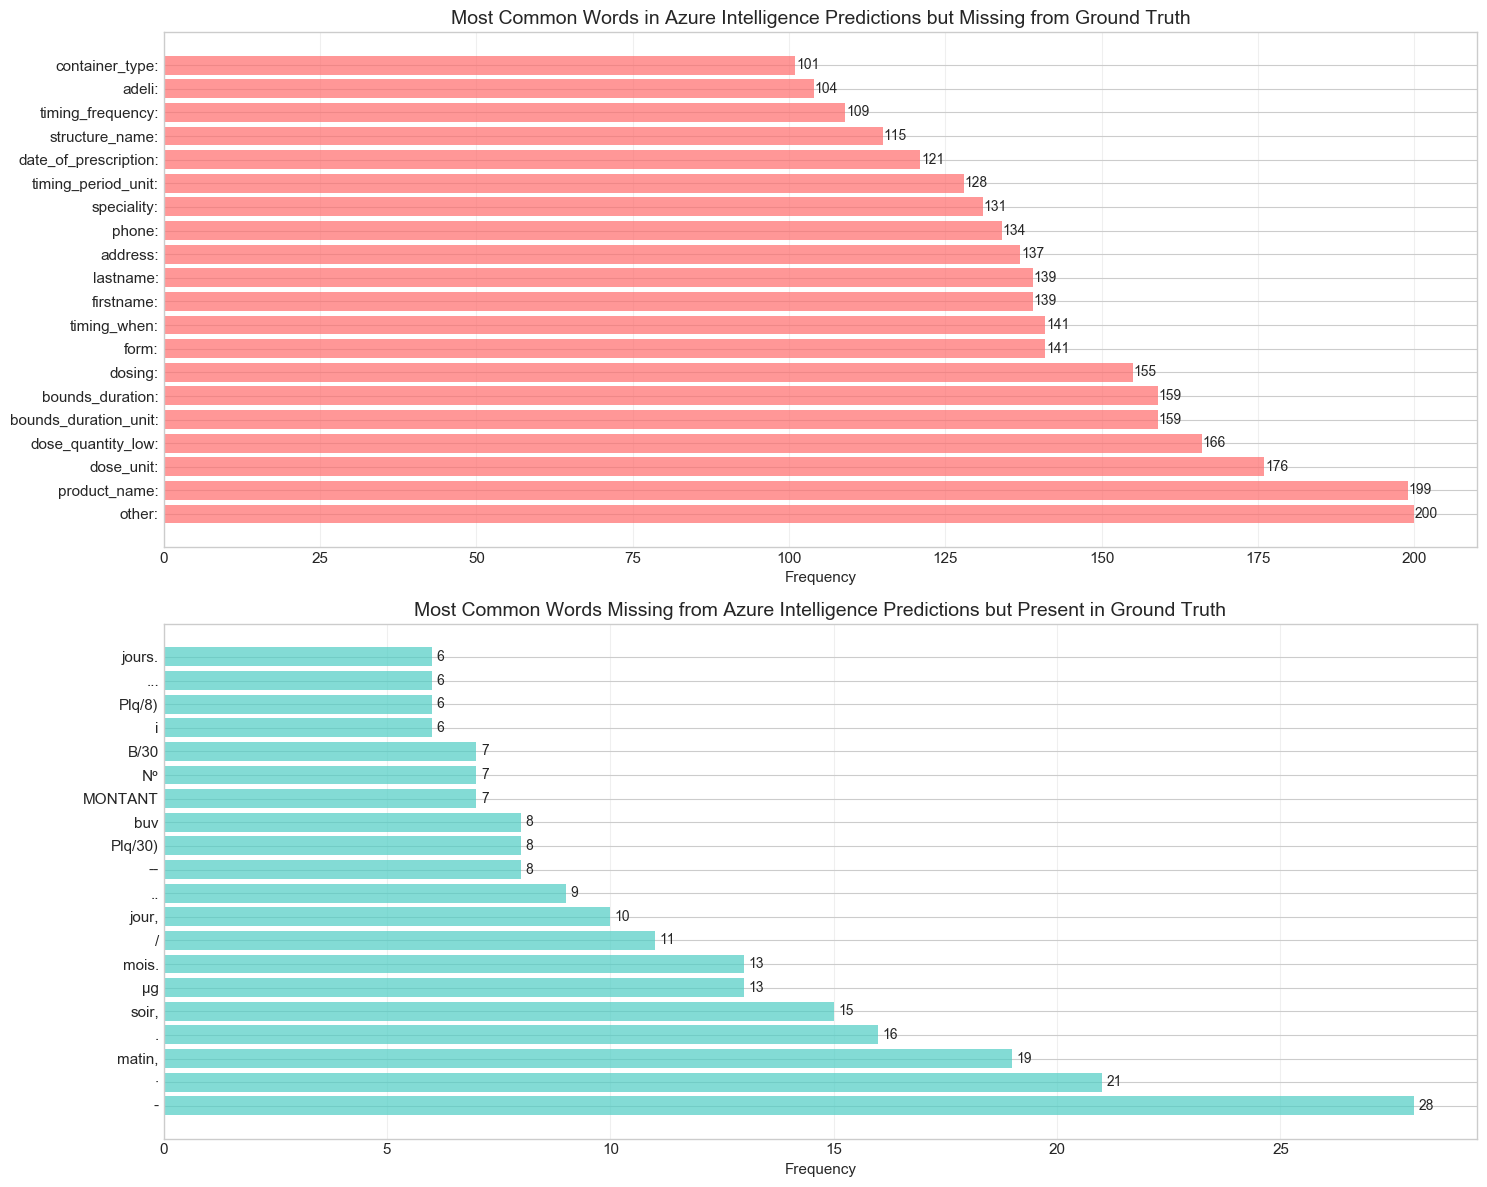


Error Pattern Summary for Azure Intelligence:
Total unique words in predictions but not in ground truth: 3243
Total unique words in ground truth but not in predictions: 1367
Total erroneous words in predictions: 11939
Total missing words from predictions: 1881

Top 5 words added incorrectly: other: (200), product_name: (199), dose_unit: (176), dose_quantity_low: (166), bounds_duration_unit: (159)
Top 5 words most frequently missed: - (28), · (21), matin, (19), . (16), soir, (15)


In [50]:
import textwrap
import difflib

# Analyze best and worst performing samples for Pa phase
if 'Pa' in phase_dfs:
    df_analysis = phase_dfs['Pa'].copy()
    
    # Get first model for analysis
    pred_cols = [col for col in df_analysis.columns if col.startswith('prediction_')]
    first_model = pred_cols[0].replace('prediction_', '')
    
    # Function to find differences between texts
    def find_text_differences(gt_text, pred_text):
        """Find words in ground truth not in prediction and vice versa."""
        if pd.isna(gt_text) or pd.isna(pred_text):
            return [], []
        
        # Split texts into words (simple whitespace split)
        gt_words = set(str(gt_text).split())
        pred_words = set(str(pred_text).split())
        
        # Find differences
        gt_not_in_pred = list(gt_words - pred_words)
        pred_not_in_gt = list(pred_words - gt_words)
        
        return gt_not_in_pred, pred_not_in_gt
    
    # Calculate CER, WER, and Cosine Similarity for each sample
    df_analysis['cer'] = df_analysis.apply(
        lambda row: calculate_cer(row['ground_truth'], row[f'prediction_{first_model}']),
        axis=1
    )
    df_analysis['wer'] = df_analysis.apply(
        lambda row: calculate_wer(row['ground_truth'], row[f'prediction_{first_model}']),
        axis=1
    )
    df_analysis['cosine_similarity'] = df_analysis.apply(
        lambda row: calculate_sample_metrics_with_cosine(
            row['ground_truth'], 
            row[f'prediction_{first_model}'], 
            'Pa', 
            row['sample_id'], 
            first_model, 
            embedding_manager
        )['cosine_similarity'],
        axis=1
    )
    
    # Calculate text differences for each sample
    df_analysis['gt_not_in_pred'], df_analysis['pred_not_in_gt'] = zip(*df_analysis.apply(
        lambda row: find_text_differences(row['ground_truth'], row[f'prediction_{first_model}']),
        axis=1
    ))
    
    # Get best and worst samples by CER
    best_samples_cer = df_analysis.nsmallest(5, 'cer')
    worst_samples_cer = df_analysis.nlargest(5, 'cer')
    
    # Get best and worst samples by Cosine Similarity
    best_samples_cosine = df_analysis.nlargest(5, 'cosine_similarity')
    worst_samples_cosine = df_analysis.nsmallest(5, 'cosine_similarity')
    
    # Set display options for full text and wrapping
    pd.set_option('display.max_colwidth', None)
    pd.set_option('display.width', None)
    
    # Function to wrap text
    def wrap_text(text, width=80):
        if pd.isna(text):
            return ""
        return textwrap.fill(str(text), width=width)
    
    # Create DataFrames for CER-based analysis
    best_df_cer = pd.DataFrame({
        'Ground Truth': best_samples_cer['ground_truth'].apply(lambda x: wrap_text(x)),
        'Prediction': best_samples_cer[f'prediction_{first_model}'].apply(lambda x: wrap_text(x)),
        'CER': best_samples_cer['cer'].round(4),
        'WER': best_samples_cer['wer'].round(4),
        'Cosine Similarity': best_samples_cer['cosine_similarity'].round(4),
        'Words in GT not in Prediction': best_samples_cer['gt_not_in_pred'],
        'Words in Prediction not in GT': best_samples_cer['pred_not_in_gt']
    })
    
    worst_df_cer = pd.DataFrame({
        'Ground Truth': worst_samples_cer['ground_truth'].apply(lambda x: wrap_text(x)),
        'Prediction': worst_samples_cer[f'prediction_{first_model}'].apply(lambda x: wrap_text(x)),
        'CER': worst_samples_cer['cer'].round(4),
        'WER': worst_samples_cer['wer'].round(4),
        'Cosine Similarity': worst_samples_cer['cosine_similarity'].round(4),
        'Words in GT not in Prediction': worst_samples_cer['gt_not_in_pred'],
        'Words in Prediction not in GT': worst_samples_cer['pred_not_in_gt']
    })
    
    # Create DataFrames for Cosine Similarity-based analysis
    best_df_cosine = pd.DataFrame({
        'Ground Truth': best_samples_cosine['ground_truth'].apply(lambda x: wrap_text(x)),
        'Prediction': best_samples_cosine[f'prediction_{first_model}'].apply(lambda x: wrap_text(x)),
        'CER': best_samples_cosine['cer'].round(4),
        'WER': best_samples_cosine['wer'].round(4),
        'Cosine Similarity': best_samples_cosine['cosine_similarity'].round(4),
        'Words in GT not in Prediction': best_samples_cosine['gt_not_in_pred'],
        'Words in Prediction not in GT': best_samples_cosine['pred_not_in_gt']
    })
    
    worst_df_cosine = pd.DataFrame({
        'Ground Truth': worst_samples_cosine['ground_truth'].apply(lambda x: wrap_text(x)),
        'Prediction': worst_samples_cosine[f'prediction_{first_model}'].apply(lambda x: wrap_text(x)),
        'CER': worst_samples_cosine['cer'].round(4),
        'WER': worst_samples_cosine['wer'].round(4),
        'Cosine Similarity': worst_samples_cosine['cosine_similarity'].round(4),
        'Words in GT not in Prediction': worst_samples_cosine['gt_not_in_pred'],
        'Words in Prediction not in GT': worst_samples_cosine['pred_not_in_gt']
    })
    
    print("\n" + "="*120)
    print(f"BEST PERFORMING SAMPLES (Lowest CER) - Model: {first_model}")
    print("="*120)
    display(best_df_cer)
    
    print("\n" + "="*120)
    print(f"WORST PERFORMING SAMPLES (Highest CER) - Model: {first_model}")
    print("="*120)
    display(worst_df_cer)
    
    print("\n" + "="*120)
    print(f"BEST PERFORMING SAMPLES (Highest Cosine Similarity) - Model: {first_model}")
    print("="*120)
    display(best_df_cosine)
    
    print("\n" + "="*120)
    print(f"WORST PERFORMING SAMPLES (Lowest Cosine Similarity) - Model: {first_model}")
    print("="*120)
    display(worst_df_cosine)

# Bag of Words Analysis for Error Patterns
print("\n" + "="*120)
print("BAG OF WORDS ANALYSIS - Common Error Patterns")
print("="*120)

from collections import Counter
import matplotlib.pyplot as plt

# Collect all erroneous words from all samples
all_pred_not_in_gt = []
all_gt_not_in_pred = []

for _, row in df_analysis.iterrows():
    all_pred_not_in_gt.extend(row['pred_not_in_gt'])
    all_gt_not_in_pred.extend(row['gt_not_in_pred'])

# Count frequencies
pred_error_counts = Counter(all_pred_not_in_gt)
gt_error_counts = Counter(all_gt_not_in_pred)

# Get top 20 most common errors for each category
top_pred_errors = pred_error_counts.most_common(20)
top_gt_errors = gt_error_counts.most_common(20)

# Create figure with two subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 12))

# Plot 1: Words in Prediction not in Ground Truth
if top_pred_errors:
    words, counts = zip(*top_pred_errors)
    bars1 = ax1.barh(range(len(words)), counts, color='#ff6b6b', alpha=0.7)
    ax1.set_yticks(range(len(words)))
    ax1.set_yticklabels(words)
    ax1.set_xlabel('Frequency')
    ax1.set_title(f'Most Common Words in {get_model_display_name(first_model)} Predictions but Missing from Ground Truth', fontsize=14, fontweight='bold')
    ax1.grid(axis='x', alpha=0.3)
    
    # Add value labels on bars
    for i, (word, count) in enumerate(top_pred_errors):
        ax1.text(count + 0.1, i, f'{count}', va='center', fontsize=10)
else:
    ax1.text(0.5, 0.5, 'No prediction errors found', ha='center', va='center', transform=ax1.transAxes)
    ax1.set_title(f'Words in {get_model_display_name(first_model)} Predictions but Missing from Ground Truth', fontsize=14, fontweight='bold')

# Plot 2: Words in Ground Truth not in Prediction
if top_gt_errors:
    words, counts = zip(*top_gt_errors)
    bars2 = ax2.barh(range(len(words)), counts, color='#4ecdc4', alpha=0.7)
    ax2.set_yticks(range(len(words)))
    ax2.set_yticklabels(words)
    ax2.set_xlabel('Frequency')
    ax2.set_title(f'Most Common Words Missing from {get_model_display_name(first_model)} Predictions but Present in Ground Truth', fontsize=14, fontweight='bold')
    ax2.grid(axis='x', alpha=0.3)
    
    # Add value labels on bars
    for i, (word, count) in enumerate(top_gt_errors):
        ax2.text(count + 0.1, i, f'{count}', va='center', fontsize=10)
else:
    ax2.text(0.5, 0.5, 'No ground truth omissions found', ha='center', va='center', transform=ax2.transAxes)
    ax2.set_title(f'Words Missing from {get_model_display_name(first_model)} Predictions but Present in Ground Truth', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# Print summary statistics
print(f"\nError Pattern Summary for {get_model_display_name(first_model)}:")
print(f"Total unique words in predictions but not in ground truth: {len(pred_error_counts)}")
print(f"Total unique words in ground truth but not in predictions: {len(gt_error_counts)}")
print(f"Total erroneous words in predictions: {sum(pred_error_counts.values())}")
print(f"Total missing words from predictions: {sum(gt_error_counts.values())}")

if top_pred_errors:
    print(f"\nTop 5 words added incorrectly: {', '.join([f'{word} ({count})' for word, count in top_pred_errors[:5]])}")

if top_gt_errors:
    print(f"Top 5 words most frequently missed: {', '.join([f'{word} ({count})' for word, count in top_gt_errors[:5]])}")

## 6. Inference Time Analysis


Inference Time Summary:


,Phase,Model,Mean Time (ms),Median Time (ms)
1,Pa,mistral_document_ai,3621.483413,2761.849523
0,Pa,azure_intelligence,3755.195106,2850.203395
2,Pb,claude_sonnet,11505.631738,10015.308619
3,Pb,gpt-5-mini,14059.395694,13238.856554
4,Pb,gpt-5-nano,21811.173574,18397.519588
5,Pc,claude_sonnet,11734.219295,10288.749337
6,Pc,gpt-5-mini,14303.016338,13591.956139
7,Pc,gpt-5-nano,17756.955955,16673.128009


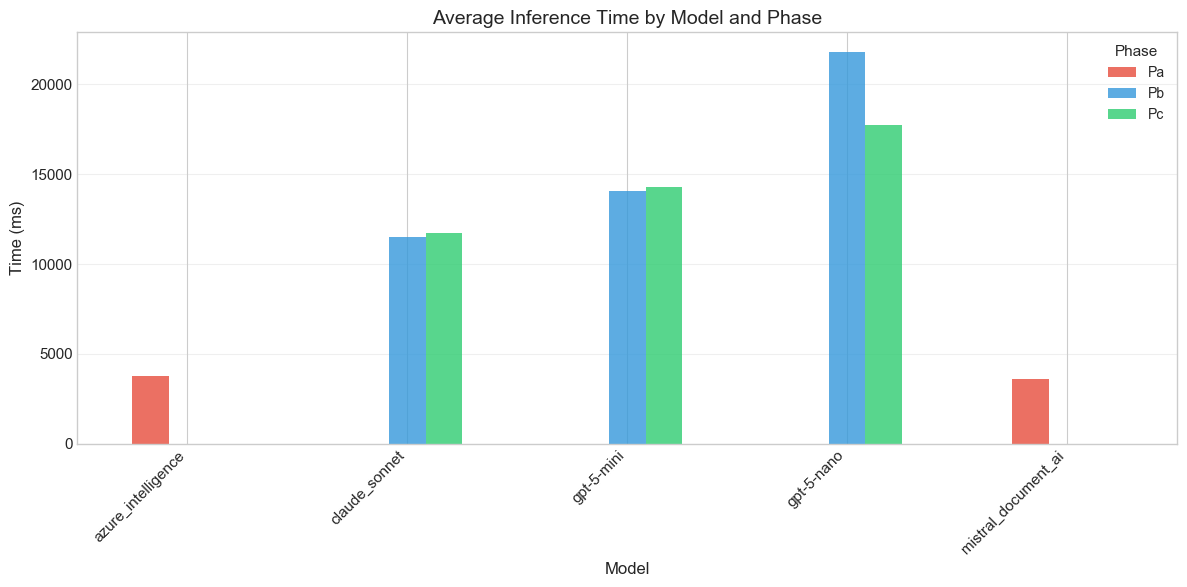

In [50]:
# Analyze inference times across models and phases
inference_data = []

for phase, df in phase_dfs.items():
    time_cols = [col for col in df.columns if col.startswith('inference_time_ms_')]
    
    for time_col in time_cols:
        model = time_col.replace('inference_time_ms_', '')
        
        mean_time = df[time_col].mean()
        median_time = df[time_col].median()
        
        inference_data.append({
            'Phase': phase,
            'Model': model,
            'Mean Time (ms)': mean_time,
            'Median Time (ms)': median_time
        })

if inference_data:
    inference_df = pd.DataFrame(inference_data)
    
    print("\nInference Time Summary:")
    print("="*100)
    display(inference_df.sort_values(['Phase', 'Mean Time (ms)']))
    
    # Visualization
    fig, ax = plt.subplots(figsize=(12, 6))
    
    pivot_time = inference_df.pivot(index='Model', columns='Phase', values='Mean Time (ms)')
    pivot_time.plot(kind='bar', ax=ax, color=['#e74c3c', '#3498db', '#2ecc71'], alpha=0.8)
    
    ax.set_title('Average Inference Time by Model and Phase', fontsize=14, fontweight='bold')
    ax.set_xlabel('Model', fontsize=12)
    ax.set_ylabel('Time (ms)', fontsize=12)
    ax.legend(title='Phase', title_fontsize=11, fontsize=10)
    ax.grid(axis='y', alpha=0.3)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    
    plt.tight_layout()
    plt.show()
else:
    print("No inference time data available")

## 8. Save Embeddings Cache

Save any newly computed embeddings to disk for faster future runs.

In [51]:
# Save any remaining embeddings to disk for future use
print("\n📁 Finalizing embedding cache...")

if embedding_manager.modified_phases:
    print(f"Saving embeddings for modified phases: {embedding_manager.modified_phases}")
    
    for phase in embedding_manager.modified_phases:
        if phase in embedding_manager.cache:
            saved_file = save_embeddings_for_phase(
                dataset_name=DATASET_NAME,
                phase=phase,
                embeddings_dict=embedding_manager.cache[phase],
                embeddings_base_dir=EMBEDDINGS_DIR
            )
            print(f"✅ Saved: {saved_file.name}")
    
    print("\n✅ All embeddings have been persisted to disk!")
else:
    print("✅ No new embeddings to save (all from cache)")


📁 Finalizing embedding cache...
✅ No new embeddings to save (all from cache)


## 9. Medical Prescription Field Analysis

Analyze how well models capture common medical prescription fields in French.

In [52]:
# Common fields in French medical prescriptions
MEDICAL_FIELDS = {
    'patient': 'Patient Name',
    'médecin': 'Doctor Name',
    'médicament': 'Medication',
    'posologie': 'Dosage',
    'durée': 'Duration',
    'date': 'Date',
    'signature': 'Signature',
    'ordonnance': 'Prescription',
    'traitement': 'Treatment',
    'comprimé': 'Tablet',
    'mg': 'Milligrams',
    'fois par jour': 'Times per day'
}

def check_field_presence(text: str, field: str) -> bool:
    """Check if a field is present in the text (case insensitive)."""
    if pd.isna(text):
        return False
    return field.lower() in str(text).lower()

# Only run if we have data
if len(phase_dfs) > 0:
    # Analyze field extraction for first available VLM phase
    for phase in ['Pc', 'Pb']:
        if phase not in phase_dfs:
            continue
            
        df = phase_dfs[phase]
        pred_cols = [col for col in df.columns if col.startswith('prediction_')]
        models = [col.replace('prediction_', '') for col in pred_cols]
        
        if not models:
            continue
            
        print(f"Field Extraction Analysis ({phase}):")
        print("=" * 80)
        
        # Analyze ground truth first
        print("\nFields present in Ground Truth:")
        for field_fr, field_en in MEDICAL_FIELDS.items():
            count = df['ground_truth'].apply(lambda x: check_field_presence(x, field_fr)).sum()
            pct = count / len(df) * 100
            if count > 0:
                print(f"  {field_fr} ({field_en}): {count}/{len(df)} ({pct:.1f}%)")
        
        # Analyze each model
        for model in models:
            pred_col = f"prediction_{model}"
            if pred_col not in df.columns:
                continue
            
            print(f"\nFields extracted by {model}:")
            for field_fr, field_en in MEDICAL_FIELDS.items():
                gt_count = df['ground_truth'].apply(lambda x: check_field_presence(x, field_fr)).sum()
                pred_count = df[pred_col].apply(lambda x: check_field_presence(x, field_fr)).sum()
                if gt_count > 0:
                    recall = pred_count / gt_count * 100
                    print(f"  {field_fr}: {pred_count}/{gt_count} ({recall:.1f}% recall)")
        
        break  # Only analyze one phase

Field Extraction Analysis (Pc):

Fields present in Ground Truth:
  patient (Patient Name): 7/200 (3.5%)
  médecin (Doctor Name): 64/200 (32.0%)
  médicament (Medication): 15/200 (7.5%)
  posologie (Dosage): 1/200 (0.5%)
  durée (Duration): 56/200 (28.0%)
  date (Date): 12/200 (6.0%)
  ordonnance (Prescription): 27/200 (13.5%)
  traitement (Treatment): 63/200 (31.5%)
  comprimé (Tablet): 93/200 (46.5%)
  mg (Milligrams): 140/200 (70.0%)
  fois par jour (Times per day): 50/200 (25.0%)

Fields extracted by claude_sonnet:
  patient: 80/7 (1142.9% recall)
  médecin: 89/64 (139.1% recall)
  médicament: 15/15 (100.0% recall)
  posologie: 1/1 (100.0% recall)
  durée: 57/56 (101.8% recall)
  date: 122/12 (1016.7% recall)
  ordonnance: 27/27 (100.0% recall)
  traitement: 63/63 (100.0% recall)
  comprimé: 93/93 (100.0% recall)
  mg: 140/140 (100.0% recall)
  fois par jour: 2/50 (4.0% recall)

Fields extracted by gpt-5-mini:
  patient: 80/7 (1142.9% recall)
  médecin: 89/64 (139.1% recall)
  médic